# BAB 4 — ANALISIS SARIMA VILLA BALI
## Prediksi Tingkat Hunian (Occupancy) | Canggu & Seminyak

## Import Library & Konfigurasi

In [ ]:
# Core
import os, warnings, time, itertools, ast
import numpy as np
import pandas as pd

# Visualisasi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.signal import periodogram as scipy_periodogram

# Statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import acf as sm_acf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox

try:
    from pmdarima import auto_arima
    print('pmdarima tersedia')
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pmdarima', '-q'])
    from pmdarima import auto_arima
    print('pmdarima berhasil diinstall')

# Sklearn
from sklearn.metrics import mean_squared_error

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (14, 5),
                     'axes.titlesize': 13, 'axes.labelsize': 11})

BASE_PATH = 'data/raw'

VILLA_CONFIG = {
    'briana_villas'  : {'area': 'canggu',   'color': '#3D6BE8'},
    'castello_villas': {'area': 'canggu',   'color': '#7c3aed'},
    'elina_villas'   : {'area': 'canggu',   'color': '#059669'},
    'isola_villas'   : {'area': 'canggu',   'color': '#db2777'},
    'eindra_villas'  : {'area': 'seminyak', 'color': '#d97706'},
    'esha_villas'    : {'area': 'seminyak', 'color': '#b45309'},
    'ozamiz_villas'  : {'area': 'seminyak', 'color': '#9333ea'},
}

print(f'Library & konfigurasi selesai. Total villa: {len(VILLA_CONFIG)}')

pmdarima tersedia
Library & konfigurasi selesai. Total villa: 7


## Helper Functions

In [ ]:
from pathlib import Path

if not os.path.exists(BASE_PATH):
    print(f'BASE_PATH tidak ditemukan: {BASE_PATH}')
else:
    migrated = list(Path(BASE_PATH).rglob('*.csv.migrated'))
    if migrated:
        for f in migrated:
            f.rename(f.with_suffix(''))
        print(f'{len(migrated)} file di-rename (.csv.migrated -> .csv)')
    print(f'BASE_PATH OK: {BASE_PATH}')

def build_path(area, villa, data_type):
    prefix = villa.replace('_villas', '_villa')
    fname  = f'{prefix}_daily_{data_type}.csv'
    return os.path.join(BASE_PATH, area, villa, fname)

def load_raw(path):
    try:
        df = pd.read_csv(path, sep=None, engine='python', encoding='utf-8-sig')
        df.columns = df.columns.str.strip()
        return df
    except FileNotFoundError:
        print(f'  File tidak ditemukan: {path}')
        return None

def parse_villa_date(series):
    s = series.astype(str).str.strip()
    parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
    if parsed.isna().mean() > 0.3:
        s = s.str.replace(r'^(Sun|Mon|Tue|Wed|Thu|Fri|Sat)\s+', '', regex=True).str.strip()
        parsed = pd.to_datetime(s, errors='coerce', dayfirst=True)
    return parsed

def parse_occupancy_to_percentage(series):
    s = series.astype(str).str.strip()
    if s.str.contains('%').any():
        result = pd.to_numeric(s.str.replace('%', '', regex=False).str.strip(), errors='coerce')
    else:
        result = pd.to_numeric(s, errors='coerce')
    if result.dropna().max() <= 1.0:
        result = result * 100.0
    return result.clip(0, 100)

def calculate_mape(actual, predicted):
    actual    = np.array(actual, dtype=float)
    predicted = np.array(predicted, dtype=float)
    denom     = (np.abs(actual) + np.abs(predicted)) / 2.0
    denom     = np.where(denom == 0, 1.0, denom)
    return float(np.mean(np.abs(actual - predicted) / denom) * 100)

def calculate_rmse(actual, predicted):
    return float(np.sqrt(mean_squared_error(actual, predicted)))

print('Helper functions loaded.')

BASE_PATH OK: data/raw
Helper functions loaded.


In [ ]:
hasil_cek = []

for villa, config in VILLA_CONFIG.items():
    area = config['area']
    df = load_raw(build_path(area, villa, 'occupancy'))

    if df is None:
        print(f'{area}/{villa}: data tidak ditemukan')
        continue

    date_col = [c for c in df.columns if 'date' in c.lower() or 'tanggal' in c.lower()][0]
    occ_col  = [c for c in df.columns if 'occ' in c.lower() or 'hunian' in c.lower()][0]

    tgl_parsed = parse_villa_date(df[date_col])
    tgl_invalid = tgl_parsed.isna().sum()
    tgl_duplikat = df[date_col].duplicated().sum()

    occ_angka = pd.to_numeric(df[occ_col].astype(str).str.replace('%', ''), errors='coerce')
    occ_luar_rentang = ((occ_angka < 0) | (occ_angka > 100)).sum()

    tipe_tanggal = df[date_col].dtype
    tipe_occupancy = df[occ_col].dtype

    print(f'\n{area}/{villa}')
    print(f'  jumlah baris        : {len(df)}')
    print(f'  tipe data tanggal   : {tipe_tanggal}')
    print(f'  tipe data occupancy : {tipe_occupancy}')
    print(f'  tanggal invalid     : {tgl_invalid}')
    print(f'  tanggal duplikat    : {tgl_duplikat}')
    print(f'  occupancy diluar 0-100% : {occ_luar_rentang}')

    hasil_cek.append({
        'Villa': f'{area}/{villa}',
        'Jumlah Baris': len(df),
        'Tipe Tanggal': tipe_tanggal,
        'Tipe Occupancy': tipe_occupancy,
        'Tanggal Invalid': tgl_invalid,
        'Tanggal Duplikat': tgl_duplikat,
        'Occ Luar Rentang': occ_luar_rentang,
    })

print('\n' + '=' * 60)
print('RINGKASAN')
ringkasan = pd.DataFrame(hasil_cek)
display(ringkasan)


canggu/briana_villas
  jumlah baris        : 1096
  tipe data tanggal   : object
  tipe data occupancy : object
  tanggal invalid     : 0
  tanggal duplikat    : 0
  occupancy diluar 0-100% : 5

canggu/castello_villas
  jumlah baris        : 1097
  tipe data tanggal   : object
  tipe data occupancy : object
  tanggal invalid     : 1
  tanggal duplikat    : 0
  occupancy diluar 0-100% : 0

canggu/elina_villas
  jumlah baris        : 1097
  tipe data tanggal   : object
  tipe data occupancy : object
  tanggal invalid     : 1
  tanggal duplikat    : 0
  occupancy diluar 0-100% : 12

canggu/isola_villas
  jumlah baris        : 1097
  tipe data tanggal   : object
  tipe data occupancy : object
  tanggal invalid     : 1
  tanggal duplikat    : 0
  occupancy diluar 0-100% : 31

seminyak/eindra_villas
  jumlah baris        : 1097
  tipe data tanggal   : object
  tipe data occupancy : object
  tanggal invalid     : 1
  tanggal duplikat    : 0
  occupancy diluar 0-100% : 3

seminyak/esha_villas

,Villa,Jumlah Baris,Tipe Tanggal,Tipe Occupancy,Tanggal Invalid,Tanggal Duplikat,Occ Luar Rentang
0,canggu/briana_villas,1096,object,object,0,0,5
1,canggu/castello_villas,1097,object,object,1,0,0
2,canggu/elina_villas,1097,object,object,1,0,12
3,canggu/isola_villas,1097,object,object,1,0,31
4,seminyak/eindra_villas,1097,object,object,1,0,3
5,seminyak/esha_villas,1097,object,object,1,0,0
6,seminyak/ozamiz_villas,1097,object,object,1,0,0


## Load & Clean Data

In [ ]:
import numpy as np
import pandas as pd


def seasonal_median_impute(series, window_months=1):
    s = series.copy()
    for idx in s[s.isna()].index:
        month = idx.month
        candidates = []
        for m_off in range(-window_months, window_months + 1):
            target_month = ((month - 1 + m_off) % 12) + 1
            same_month = s[(s.index.month == target_month) & ~s.isna()]
            candidates.extend(same_month.values.tolist())
        if candidates:
            s[idx] = np.median(candidates)
        else:
            s[idx] = s.median()
    return s


def clean_occupancy(df, villa_name, impute_zero=True):
    sep = '=' * 65
    df = df.copy()
    print(f'\n{sep}')
    print(f'[{villa_name}]  shape={df.shape}  (impute_zero={impute_zero})')

    date_cands = [c for c in df.columns if any(k in c.lower() for k in ['date','tanggal','tgl'])]
    date_col   = date_cands[0] if date_cands else df.columns[0]

    occ_exact = [c for c in df.columns if c.lower().strip() == 'occupancy']
    occ_kw    = [c for c in df.columns
                 if any(k in c.lower() for k in ['occ','hunian','occupied']) and c not in occ_exact]
    occ_col   = (occ_exact + occ_kw)[0] if (occ_exact + occ_kw) else None

    use_computed = False
    if occ_col is None:
        booked_c = [c for c in df.columns if 'booked' in c.lower()]
        avail_c  = [c for c in df.columns if 'available' in c.lower()]
        if booked_c and avail_c:
            use_computed = True
            booked_col, avail_col = booked_c[0], avail_c[0]
        else:
            occ_col = df.select_dtypes(include=np.number).columns[0]

    print(f'  date_col="{date_col}" | occ_col="{occ_col}"')

    raw_dates = df[date_col].copy()
    df[date_col] = parse_villa_date(df[date_col])

    invalid_rows = df[df[date_col].isna()]
    if len(invalid_rows) > 0:
        print(f'  Tanggal invalid ({len(invalid_rows)} baris), contoh:')
        print(invalid_rows[[date_col]].assign(**{date_col: raw_dates[invalid_rows.index]}).head(3).to_string(index=False))

    df = df.dropna(subset=[date_col]).sort_values(date_col)

    dup_rows = df[df[date_col].duplicated(keep=False)]
    if len(dup_rows) > 0:
        n_dup = df[date_col].duplicated().sum()
        print(f'  Tanggal duplikat ({dup_rows[date_col].nunique()} tanggal), contoh:')
        print(dup_rows[[date_col, occ_col]].head(4).to_string(index=False))
        df = df.drop_duplicates(subset=[date_col], keep='last')
    else:
        n_dup = 0

    df = df.set_index(date_col)

    if not use_computed:
        occ_raw = pd.to_numeric(df[occ_col].astype(str).str.replace('%', '', regex=False).str.strip(), errors='coerce')
        out_of_range_rows = df[(occ_raw < 0) | (occ_raw > 100)]
        if len(out_of_range_rows) > 0:
            print(f'  Occupancy di luar rentang 0-100% ({len(out_of_range_rows)} baris), contoh:')
            print(out_of_range_rows[[occ_col]].head(3).to_string(index=True))
        n_out_of_range = len(out_of_range_rows)
    else:
        n_out_of_range = 0

    print(f'  Ringkasan kotor -> invalid: {len(invalid_rows)} | duplikat: {n_dup} | luar rentang: {n_out_of_range}')

    if use_computed:
        total  = df[booked_col].add(df[avail_col])
        series = (df[booked_col] / total.replace(0, np.nan)).rename('occupancy') * 100.0
    else:
        series = parse_occupancy_to_percentage(df[occ_col]).rename('occupancy')

    # ===== DEBUG: cek skala sebelum clip nanti (lihat apakah ada nilai jauh >100) =====
    print(f'  [DEBUG raw] min={series.min():.1f} | max={series.max():.1f} | median={series.median():.1f}')
    # ====================================================================================

    # ===== Cek & (opsional) imputasi occupancy 0% =====
    n_zero = int((series == 0).sum())
    if n_zero > 0:
        print(f'  Occupancy 0% ditemukan: {n_zero} hari', end='')
        if impute_zero:
            print(' -> akan diimputasi')
            series = series.replace(0, np.nan)
        else:
            print(' -> DIPERTAHANKAN (raw, tidak diimputasi)')
    # =====================================================

    full_idx = pd.date_range(series.index.min(), series.index.max(), freq='D')
    series   = series.reindex(full_idx)

    n_missing_before = series.isna().sum()
    if n_missing_before > 0:
        monthly_temp = series.resample('MS').mean()
        monthly_temp = seasonal_median_impute(monthly_temp)
        series = series.interpolate(method='time', limit=3)
        for idx in series[series.isna()].index:
            month = idx.month
            same_month_vals = series[(series.index.month == month) & ~series.isna()]
            if len(same_month_vals) > 0:
                series[idx] = same_month_vals.median()
            else:
                series[idx] = series.median()

    series = series.clip(0, 100)
    n_missing_after = series.isna().sum()

    print(f'  Missing: {n_missing_before} hari -> setelah impute: {n_missing_after}')
    print(f'  Range: {series.index.min().date()} - {series.index.max().date()}')
    print(f'  Stats: mean={series.mean():.1f}% | std={series.std():.1f}% | '
          f'min={series.min():.1f}% | max={series.max():.1f}%')

    clean_occupancy.last_n_zero_imputed = n_zero
    return series


def check_full_zero_months(series, villa_name, verbose=True):
    """Cek bulan-bulan dengan occupancy rata-rata 0% penuh (dari data RAW / belum diimputasi)."""
    monthly = series.resample('MS').mean()
    zero_months = monthly[monthly == 0]
    total_months = len(monthly)
    pct = (len(zero_months) / total_months * 100) if total_months > 0 else 0
    if verbose and len(zero_months) > 0:
        print(f'[{villa_name}] Bulan occupancy 0% penuh: {len(zero_months)}/{total_months} ({pct:.1f}%)')
        print(f'  -> {zero_months.index.strftime("%b %Y").tolist()}')
    return zero_months, pct


# ============================================================
# LOAD SEMUA VILLA — 2 versi: raw (0% asli) & imputed (0%->NaN->impute)
# ============================================================
clean_occ_raw = {}   # occupancy 0% DIPERTAHANKAN apa adanya
clean_occ     = {}   # occupancy 0% SUDAH diimputasi (versi kerja utama)
zero_occupancy_report = {}
full_zero_month_report = {}

sep = '=' * 65
print(sep)
print('LOADING & CLEANING DATA')
print(sep)

for villa, config in VILLA_CONFIG.items():
    area = config['area']
    df   = load_raw(build_path(area, villa, 'occupancy'))
    if df is not None:
        # versi raw: 0% tidak diutak-atik
        clean_occ_raw[villa] = clean_occupancy(df, f'{area}/{villa}', impute_zero=False)

        # versi imputed: 0% diganti NaN lalu diimputasi
        clean_occ[villa] = clean_occupancy(df, f'{area}/{villa}', impute_zero=True)
        n_zero = getattr(clean_occupancy, 'last_n_zero_imputed', 0)
        if n_zero > 0:
            zero_occupancy_report[f'{area}/{villa}'] = n_zero
    else:
        print(f'\n  [{area}/{villa}] Data tidak ditemukan!')

print(f'\n{len(clean_occ)} villa berhasil di-load.')

# ===== Rekap harian: villa dengan occupancy 0% =====
print(f'\n{sep}')
print('REKAP OCCUPANCY 0% (HARIAN) YANG DIIMPUTASI DI VERSI clean_occ')
print(sep)
if zero_occupancy_report:
    for villa_name, n_zero in sorted(zero_occupancy_report.items(), key=lambda x: -x[1]):
        print(f'  {villa_name}: {n_zero} hari')
else:
    print('  Tidak ada villa dengan occupancy 0%.')

# ===== Rekap bulanan: villa dengan bulan 0% PENUH (dari data RAW) =====
print(f'\n{sep}')
print('REKAP BULAN OCCUPANCY 0% PENUH (dari clean_occ_raw, sebelum diimputasi)')
print(sep)
any_full_zero = False
for villa, series in clean_occ_raw.items():
    zero_months, pct = check_full_zero_months(series, villa)
    if len(zero_months) > 0:
        any_full_zero = True
        full_zero_month_report[villa] = {
            'n_months': len(zero_months),
            'pct': pct,
            'months': zero_months.index.strftime('%b %Y').tolist()
        }
if not any_full_zero:
    print('  Tidak ada villa dengan bulan occupancy 0% penuh.')

LOADING & CLEANING DATA

[canggu/briana_villas]  shape=(1096, 12)  (impute_zero=False)
  date_col="Date" | occ_col="Occupancy Total"
  Occupancy di luar rentang 0-100% (5 baris), contoh:
           Occupancy Total
Date                      
2024-10-09            200%
2024-10-10            200%
2024-10-11            200%
  Ringkasan kotor -> invalid: 0 | duplikat: 0 | luar rentang: 5
  [DEBUG raw] min=0.0 | max=100.0 | median=100.0
  Occupancy 0% ditemukan: 334 hari -> DIPERTAHANKAN (raw, tidak diimputasi)
  Missing: 0 hari -> setelah impute: 0
  Range: 2023-01-01 - 2025-12-31
  Stats: mean=69.5% | std=46.1% | min=0.0% | max=100.0%

[canggu/briana_villas]  shape=(1096, 12)  (impute_zero=True)
  date_col="Date" | occ_col="Occupancy Total"
  Occupancy di luar rentang 0-100% (5 baris), contoh:
           Occupancy Total
Date                      
2024-10-09            200%
2024-10-10            200%
2024-10-11            200%
  Ringkasan kotor -> invalid: 0 | duplikat: 0 | luar rentang: 5


In [ ]:
def find_truncate_start(series, villa_name, min_consecutive_zero_months=3):
    """Cari tanggal mulai operasi = akhir dari blok 0% pertama yang panjang (di awal data)."""
    monthly = series.resample('MS').mean()
    
    # cek dari awal, berapa bulan berturut-turut 0% sebelum ada nilai >0
    first_nonzero_idx = None
    for i, val in enumerate(monthly):
        if val > 0:
            first_nonzero_idx = i
            break
    
    if first_nonzero_idx is None:
        print(f'[{villa_name}] Semua bulan 0%, tidak ada data valid.')
        return None
    
    if first_nonzero_idx >= min_consecutive_zero_months:
        start_date = monthly.index[first_nonzero_idx]
        print(f'[{villa_name}] Blok 0% awal: {first_nonzero_idx} bulan '
              f'({monthly.index[0].strftime("%b %Y")} - {monthly.index[first_nonzero_idx-1].strftime("%b %Y")})')
        print(f'[{villa_name}] Rekomendasi truncate mulai: {start_date.strftime("%Y-%m-%d")}')
        return start_date
    else:
        print(f'[{villa_name}] Tidak ada blok 0% awal yang signifikan (< {min_consecutive_zero_months} bulan).')
        return None

# jalankan untuk castello
truncate_start = find_truncate_start(clean_occ_raw['elina_villas'], 'elina_villas')

[elina_villas] Tidak ada blok 0% awal yang signifikan (< 3 bulan).


In [ ]:
# Setelah investigasi manual, tetapkan per-villa treatment
villa_treatment = {
    'isola_villas': {'action': 'truncate', 'start_date': '2023-11-01'},
    'castello_villas': {'action': 'truncate', 'start_date': '2023-09-01'},  # potong periode belum operasi
    'elina_villas': {'action': 'keep_raw'},   # pertahankan 0% asli, pola tidak jelas cukup untuk diimputasi
    # villa lain default: keep_raw juga, kecuali ada bukti kuat sebaliknya
}

clean_occ_final = {}
for villa, series in clean_occ_raw.items():
    treatment = villa_treatment.get(villa, {'action': 'keep_raw'})
    if treatment['action'] == 'truncate':
        clean_occ_final[villa] = series[treatment['start_date']:]
    else:
        clean_occ_final[villa] = series  # 0% asli dipertahankan

## Visualisasi EDA — Akumulasi Skala Bulanan

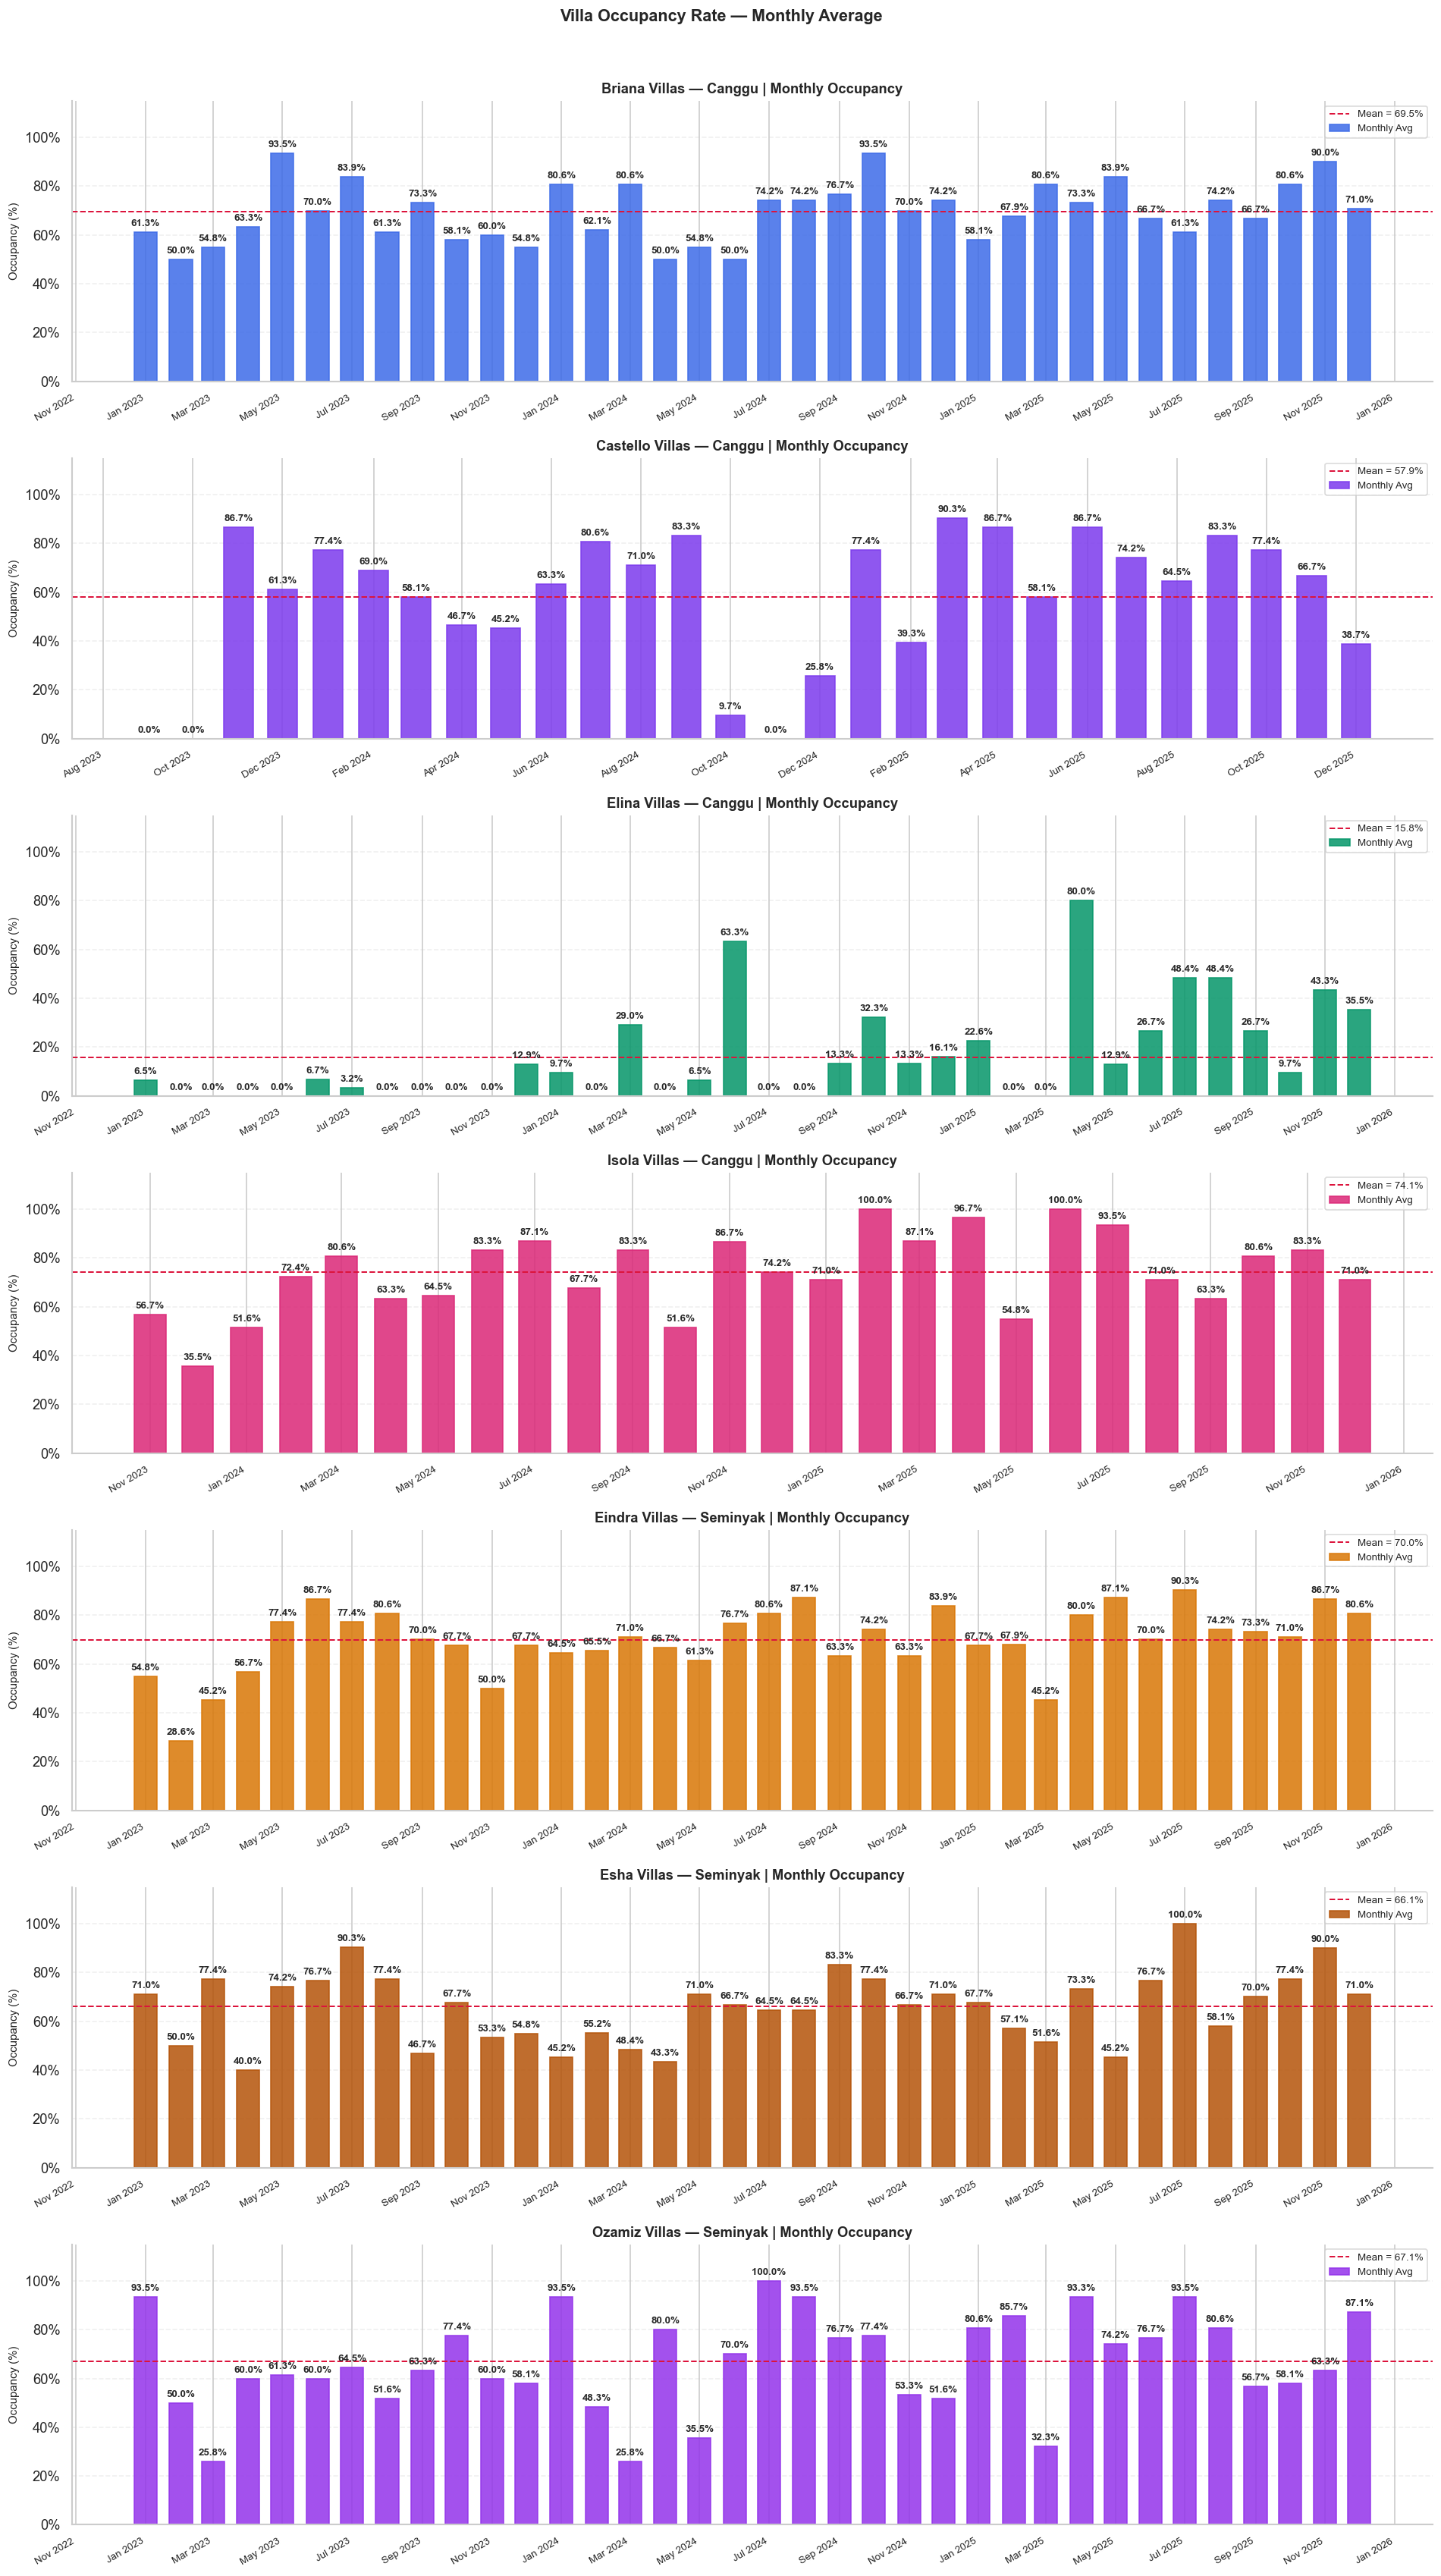

In [ ]:
fig, axes = plt.subplots(len(clean_occ_final), 1, figsize=(16, 4 * len(clean_occ_final)))
if len(clean_occ_final) == 1:
    axes = [axes]

for idx, (villa, series) in enumerate(clean_occ_final.items()):
    ax       = axes[idx]
    config   = VILLA_CONFIG[villa]
    monthly  = series.resample('MS').mean()
    mean_val = series.mean()

    # Membuat grafik batang dan menyimpannya ke dalam variabel 'bars'
    bars = ax.bar(monthly.index, monthly.values, width=20, alpha=0.85, 
                  color=config['color'], edgecolor=config['color'], label='Monthly Avg')
    
    # MENAMBAHKAN NILAI DI ATAS SETIAP BATANG
    # fmt='%.1f%%' mengatur agar muncul 1 angka di belakang koma diikuti tanda %
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=8, fontweight='semibold')
    
    # Tetap mempertahankan garis rata-rata (Mean)
    ax.axhline(mean_val, color='crimson', ls='--', lw=1.2,
               label=f'Mean = {mean_val:.1f}%')
    
    ax.set_title(f"{villa.replace('_',' ').title()} — {config['area'].title()} | Monthly Occupancy",
                 fontweight='bold', fontsize=11, pad=6)
    ax.set_ylabel('Occupancy (%)', fontsize=9)
    ax.set_ylim(0, 115) # Menaikkan sedikit limit Y agar teks di atas batang tidak terpotong
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    ax.grid(axis='y', alpha=0.3, ls='--')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(loc='upper right', fontsize=8, framealpha=0.7)

plt.suptitle('Villa Occupancy Rate — Monthly Average', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_occupancy_monthly.png', dpi=150, bbox_inches='tight')
plt.show()

## Statistik Deskriptif

In [ ]:
stats_data = []
for villa, series in clean_occ_final.items():
    config = VILLA_CONFIG[villa]
    monthly = series.resample('MS').mean()
    treatment = villa_treatment.get(villa, {'action': 'keep_raw'})
    stats_data.append({
        'Villa'      : villa.replace('_villas','').title(),
        'Area'       : config['area'].title(),
        'Treatment'  : treatment['action'],
        'N (hari)'   : len(series),
        'N (bulan)'  : len(monthly),
        'Mean (%)'   : round(series.mean(), 2),
        'Std (%)'    : round(series.std(), 2),
        'Min (%)'    : round(series.min(), 2),
        'Max (%)'    : round(series.max(), 2),
        'Median (%)' : round(series.median(), 2),
        '% Hari 0%'  : round((series == 0).mean() * 100, 1),
        '% Hari 100%': round((series == 100).mean() * 100, 1),
        'Start'      : series.index.min().strftime('%Y-%m-%d'),
        'End'        : series.index.max().strftime('%Y-%m-%d'),
    })

stats_df = pd.DataFrame(stats_data)
print('STATISTIK DESKRIPTIF OCCUPANCY (0-100%) — setelah truncate/keep_raw treatment')
print('=' * 110)
display(stats_df)

STATISTIK DESKRIPTIF OCCUPANCY (0-100%) — setelah truncate/keep_raw treatment


,Villa,Area,Treatment,N (hari),N (bulan),Mean (%),Std (%),Min (%),Max (%),Median (%),% Hari 0%,% Hari 100%,Start,End
0,Briana,Canggu,keep_raw,1096,36,69.53,46.05,0,100,100.00,30.50,69.50,2023-01-01,2025-12-31
1,Castello,Canggu,truncate,853,28,57.91,49.40,0,100,100.00,42.10,57.90,2023-09-01,2025-12-31
2,Elina,Canggu,keep_raw,1096,36,15.78,36.48,0,100,0.00,84.20,15.80,2023-01-01,2025-12-31
3,Isola,Canggu,truncate,792,26,74.12,43.83,0,100,100.00,25.90,74.10,2023-11-01,2025-12-31
4,Eindra,Seminyak,keep_raw,1096,36,69.98,45.85,0,100,100.00,30.00,70.00,2023-01-01,2025-12-31
5,Esha,Seminyak,keep_raw,1096,36,66.06,47.37,0,100,100.00,33.90,66.10,2023-01-01,2025-12-31
6,Ozamiz,Seminyak,keep_raw,1096,36,67.06,47.02,0,100,100.00,32.90,67.10,2023-01-01,2025-12-31


## Periodogram

In [ ]:
MIN_CYCLES = 2
ACF_ALPHA  = 0.10
FALLBACK_M = 6

# ===== FIX: hanya periode musiman yang masuk akal untuk data bulanan =====
# 3  = kuartalan, 4 = per-4bulan (triwulan), 6 = semesteran, 12 = tahunan
VALID_SEASONAL_PERIODS = [3, 4, 6, 12]
# ============================================================================


def detect_m(monthly, villa_label, min_cycles=MIN_CYCLES, fallback=FALLBACK_M):
    n     = len(monthly)
    MAX_M = max(n // 4, 4)

    freqs, power = scipy_periodogram(monthly.values)
    valid_mask   = freqs[1:] > 0
    periods_raw  = 1.0 / freqs[1:][valid_mask]
    power_raw    = power[1:][valid_mask]
    freqs_valid  = freqs[1:][valid_mask]

    periods_int  = np.round(periods_raw).astype(int)
    period_power = {}
    for p, pw in zip(periods_int, power_raw):
        if p not in period_power or pw > period_power[p]:
            period_power[p] = pw

    period_freq_map = {}
    for f_raw, p, pw in zip(freqs_valid, periods_int, power_raw):
        if p not in period_freq_map or pw > period_power[p]:
            period_freq_map[p] = (f_raw, pw)

    sorted_periods = sorted(period_power, key=period_power.get, reverse=True)
    top5 = sorted_periods[:5]

    # ===== FIX: pgram_m hanya dipilih dari daftar periode yang valid secara bisnis =====
    candidate_m = [p for p in VALID_SEASONAL_PERIODS if p <= MAX_M]
    pgram_m = None
    for p in sorted_periods:
        if p in candidate_m:
            pgram_m = int(p)
            break
    # =======================================================================================

    nlags = min(n // 2, 24)
    try:
        acf_vals, ci = sm_acf(monthly, nlags=nlags, alpha=ACF_ALPHA, fft=True)
        acf_spike_m  = None
        # ===== FIX: ACF juga hanya dicek pada periode yang valid =====
        for lag in candidate_m:
            if lag <= nlags:
                outside = (acf_vals[lag] > ci[lag][1] - acf_vals[lag] or
                           acf_vals[lag] < ci[lag][0] - acf_vals[lag])
                if outside:
                    acf_spike_m = lag
                    break
        # =================================================================
    except Exception:
        acf_spike_m = None

    if pgram_m is not None:
        m_final, method = pgram_m, 'periodogram'
    elif acf_spike_m is not None:
        m_final, method = acf_spike_m, 'acf_only'
    else:
        m_final, method = fallback, 'fallback'

    m_final = min(m_final, MAX_M)

    return m_final, method, {
        'pgram_m'        : pgram_m,
        'acf_spike'      : acf_spike_m,
        'n'              : n,
        'MAX_M'          : MAX_M,
        'top5_periods'   : top5,
        'period_freq_map': period_freq_map,
    }


villa_m       = {}
m_det_results = []

print('DETEKSI PERIODE DOMINAN (m) — PERIODOGRAM + ACF  [NO PLOT MODE]')
print(f'Batas: MAX_M = n // 4 | Kandidat periode valid: {VALID_SEASONAL_PERIODS}')
print('=' * 70)

for villa, series in clean_occ_final.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    area    = VILLA_CONFIG[villa]['area'].title()
    m_final, method, detail = detect_m(monthly, title)
    villa_m[villa] = m_final

    status = 'OK' if method != 'fallback' else 'fallback'
    print(f'  [{title:20s}]  n={detail["n"]:>3}  MAX_M={detail["MAX_M"]:>3}  '
          f'pgram={str(detail["pgram_m"]):>5}  acf={str(detail["acf_spike"]):>5}  '
          f'-> m={m_final}  ({method})  {status}')

    m_det_results.append({
        'Villa'        : title,
        'Area'         : area,
        'N (bln)'      : detail['n'],
        'MAX_M (n//4)' : detail['MAX_M'],
        'm terpilih'   : m_final,
        'Metode'       : method,
        'Top-5 pgram'  : str(detail['top5_periods']),
        'Status'       : 'OK' if method != 'fallback' else 'fallback',
    })

print('=' * 70)

m_df = pd.DataFrame(m_det_results)
display(m_df[['Villa', 'Area', 'N (bln)', 'MAX_M (n//4)', 'm terpilih', 'Metode', 'Status']])


def freq_legacy_format(freq, decimals=4):
    rounded = round(freq, decimals)
    s = f"{rounded:.{decimals}f}"
    sign = ''
    if s.startswith('-'):
        sign, s = '-', s[1:]
    int_part, dec_part = s.split('.')
    digits = (int_part if int_part != '0' else '') + dec_part
    digits = digits.lstrip('0') or '0'
    return sign + f"{int(digits):,}"


MANUAL_FREQ_OVERRIDE = {
    # kosongkan dulu -> nilai lama tidak valid lagi (n sudah berubah karena truncate + filter m)
}


final_rows = []

for villa, series in clean_occ_final.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()

    m_final, method, detail = detect_m(monthly, title)
    pfm   = detail['period_freq_map']
    top5  = detail['top5_periods']
    MAX_M = detail['MAX_M']

    rows_for_villa = []

    # kandidat kedua: top-1 dari periodogram MENTAH (tanpa filter), untuk transparansi
    # -> ditampilkan sebagai perbandingan, TAPI TIDAK dipakai sebagai m_final model
    top_overall = top5[0] if top5 else m_final
    if top_overall != m_final and top_overall in pfm:
        f_raw, pw = pfm[top_overall]
        if top_overall in VALID_SEASONAL_PERIODS:
            label = f"{top_overall} Bulan"
        else:
            label = f"{top_overall} Bulan (Ditolak — bukan periode musiman baku)"
        rows_for_villa.append((top_overall, f_raw, pw, label))

    f_raw_final, pw_final = pfm[m_final]
    rows_for_villa.append((m_final, f_raw_final, pw_final, f"{m_final} Bulan (Terpilih)"))

    for rank, (period, f_raw, pw, label) in enumerate(rows_for_villa):
        override_key = (title, period)
        if override_key in MANUAL_FREQ_OVERRIDE:
            freq_str = MANUAL_FREQ_OVERRIDE[override_key]
        else:
            freq_str = freq_legacy_format(f_raw)

        final_rows.append({
            'Nama Vila'                       : title if rank == 0 else '',
            'Frekuensi (f)'                   : freq_str,
            'Kerapatan Daya (Spectral Power)' : f'{pw:,.2f}'.replace(',', 'X').replace('.', ',').replace('X', '.'),
            'Kandidat Orde Musiman (s)'       : label,
        })

final_table = pd.DataFrame(final_rows)
display(final_table)

# Simpan ke Excel/CSV kalau perlu diexport rapi ke Word/laporan
# final_table.to_excel('tabel_kandidat_musiman.xlsx', index=False)

DETEKSI PERIODE DOMINAN (m) — PERIODOGRAM + ACF  [NO PLOT MODE]
Batas: MAX_M = n // 4 | Kandidat periode valid: [3, 4, 6, 12]
  [Briana              ]  n= 36  MAX_M=  9  pgram=    3  acf=    3  -> m=3  (periodogram)  OK
  [Castello            ]  n= 28  MAX_M=  7  pgram=    3  acf= None  -> m=3  (periodogram)  OK
  [Elina               ]  n= 36  MAX_M=  9  pgram=    3  acf=    3  -> m=3  (periodogram)  OK
  [Isola               ]  n= 26  MAX_M=  6  pgram=    4  acf= None  -> m=4  (periodogram)  OK
  [Eindra              ]  n= 36  MAX_M=  9  pgram=    6  acf= None  -> m=6  (periodogram)  OK
  [Esha                ]  n= 36  MAX_M=  9  pgram=    4  acf= None  -> m=4  (periodogram)  OK
  [Ozamiz              ]  n= 36  MAX_M=  9  pgram=    3  acf= None  -> m=3  (periodogram)  OK


,Villa,Area,N (bln),MAX_M (n//4),m terpilih,Metode,Status
0,Briana,Canggu,36,9,3,periodogram,OK
1,Castello,Canggu,28,7,3,periodogram,OK
2,Elina,Canggu,36,9,3,periodogram,OK
3,Isola,Canggu,26,6,4,periodogram,OK
4,Eindra,Seminyak,36,9,6,periodogram,OK
5,Esha,Seminyak,36,9,4,periodogram,OK
6,Ozamiz,Seminyak,36,9,3,periodogram,OK


,Nama Vila,Frekuensi (f),Kerapatan Daya (Spectral Power),Kandidat Orde Musiman (s)
0,Briana,"1,389","2.006,82",7 Bulan (Ditolak — bukan periode musiman baku)
1,,"3,056","88,90",3 Bulan (Terpilih)
2,Castello,"1,429","7.950,88",7 Bulan (Ditolak — bukan periode musiman baku)
3,,"3,214","1.145,48",3 Bulan (Terpilih)
4,Elina,278,"3.222,94",36 Bulan (Ditolak — bukan periode musiman baku)
5,,"3,056","2.266,60",3 Bulan (Terpilih)
6,Isola,385,"1.485,72",26 Bulan (Ditolak — bukan periode musiman baku)
7,,"2,308","1.090,26",4 Bulan (Terpilih)
8,Eindra,833,"1.792,80",12 Bulan
9,,"1,667","776,75",6 Bulan (Terpilih)


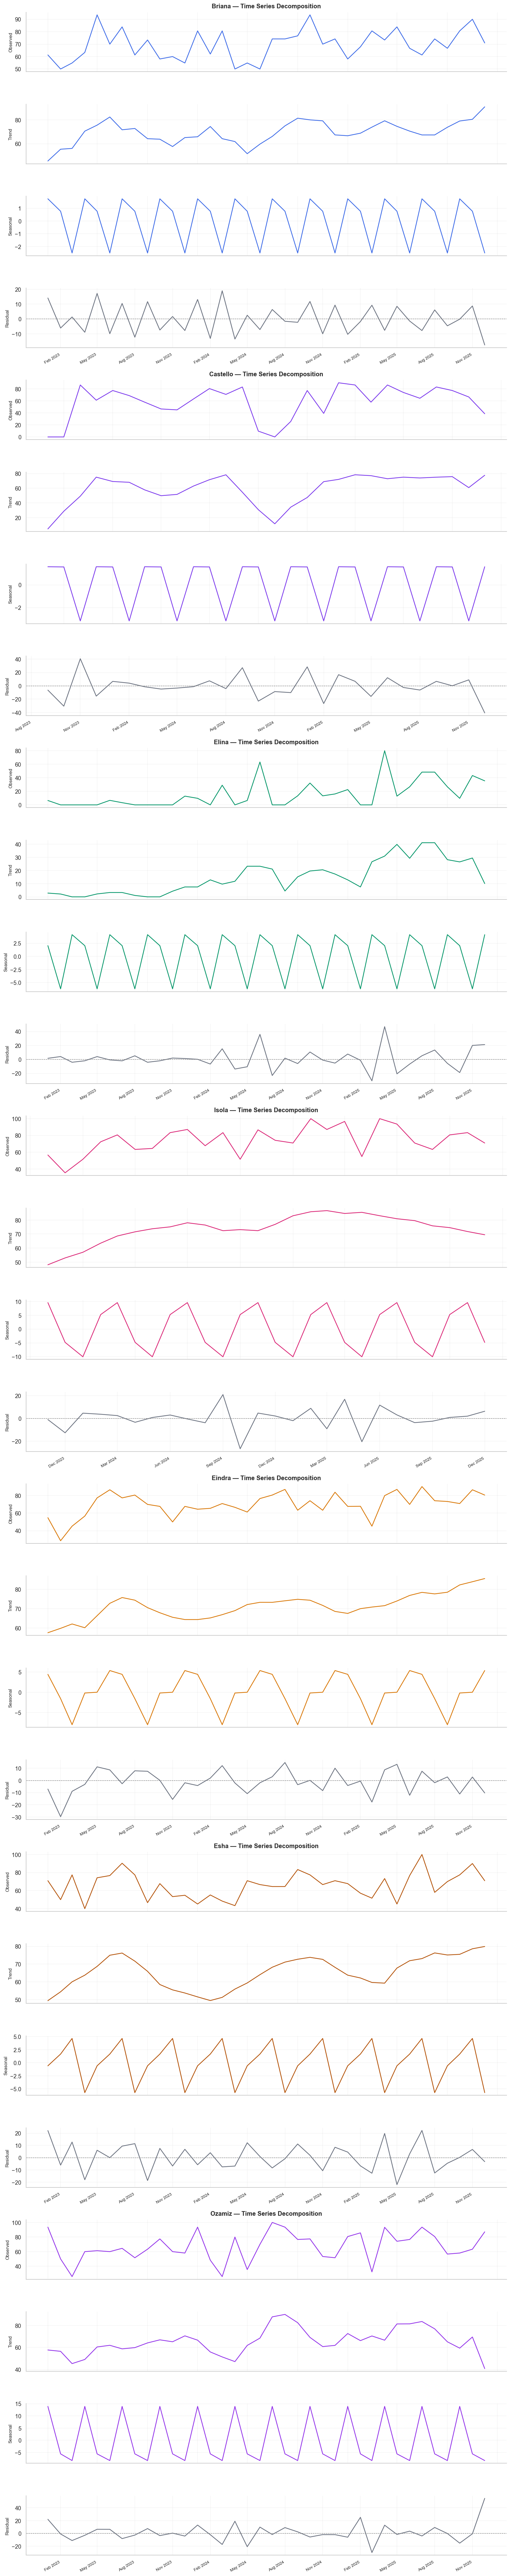

Seasonal decomposition seluruh villa digabungkan selesai.


In [ ]:
# Hitung berapa jumlah villa yang memenuhi syarat >= 24 bulan untuk menentukan ukuran grid
valid_villas = []
for villa, series in clean_occ_final.items():
    if len(series.resample('MS').mean().dropna()) >= 24:
        valid_villas.append((villa, series))

num_villas = len(valid_villas)

if num_villas == 0:
    print("Tidak ada villa dengan data >= 24 bulan.")
else:
    # Membuat 1 canvas besar: 4 baris per villa (Total baris = 4 * jumlah_villa)
    fig, axes = plt.subplots(num_villas * 4, 1, figsize=(14, 2.5 * num_villas * 4), sharex=False)
    
    # Pastikan axes berupa array jika hanya ada 1 villa yang valid
    if num_villas == 1:
        axes = axes.flatten()

    for idx, (villa, series) in enumerate(valid_villas):
        monthly = series.resample('MS').mean().dropna()
        m_villa = villa_m.get(villa, 6) if 'villa_m' in dir() else 6
        decomp  = seasonal_decompose(monthly, model='additive', period=m_villa, extrapolate_trend='freq')
        
        color   = VILLA_CONFIG[villa]['color']
        title   = villa.replace('_villas','').title()
        
        # Tentukan letak index awal baris untuk villa ke-idx
        start_row = idx * 4
        
        components = [
            (decomp.observed, 'Observed'),
            (decomp.trend, 'Trend'),
            (decomp.seasonal, 'Seasonal'),
            (decomp.resid, 'Residual')
        ]
        
        for i, (comp, label) in enumerate(components):
            ax = axes[start_row + i]
            ax.plot(monthly.index, comp, color=color if label != 'Residual' else '#6b7280', lw=1.5)
            
            if label == 'Residual':
                ax.axhline(0, color='gray', ls='--', lw=0.8)
                
            ax.set_ylabel(label, fontsize=9)
            ax.grid(alpha=0.2)
            ax.spines[['top','right']].set_visible(False)
            
            # Berikan judul utama hanya di baris pertama tiap villa (Observed)
            if i == 0:
                ax.set_title(f'{title} — Time Series Decomposition', fontweight='bold', fontsize=12, pad=8)
            
            # Konfigurasi sumbu X hanya di baris terakhir tiap villa (Residual) agar plot tidak menumpuk
            if i == 3:
                ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
                ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
                plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
            else:
                # Sembunyikan label X untuk komponen Observed, Trend, dan Seasonal demi kerapian
                ax.set_xticklabels([])

    plt.tight_layout()
    # Menyimpan seluruh dekomposisi ke dalam 1 file gambar tunggal
    plt.savefig('all_villas_decomposition.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Seasonal decomposition seluruh villa digabungkan selesai.')

UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (alpha = 5%)
   Villa     Area  N (bln)  ADF (level)  p (level) p (diff1)  d dipakai                      Keterangan
  Briana   Canggu       36        -1.62       0.47      0.00          1    Diff(1) -> stasioner (p=0.0)
Castello   Canggu       28        -3.91       0.00         -          0                 Stasioner (d=0)
   Elina   Canggu       36        -1.22       0.67      0.02          1 Diff(1) -> stasioner (p=0.0247)
   Isola   Canggu       26        -4.19       0.00         -          0                 Stasioner (d=0)
  Eindra Seminyak       36        -3.77       0.00         -          0                 Stasioner (d=0)
    Esha Seminyak       36        -5.02       0.00         -          0                 Stasioner (d=0)
  Ozamiz Seminyak       36        -5.67       0.00         -          0                 Stasioner (d=0)

villa_d = {'briana_villas': 1, 'castello_villas': 0, 'elina_villas': 1, 'isola_villas': 0, 'eindra_villas': 0,

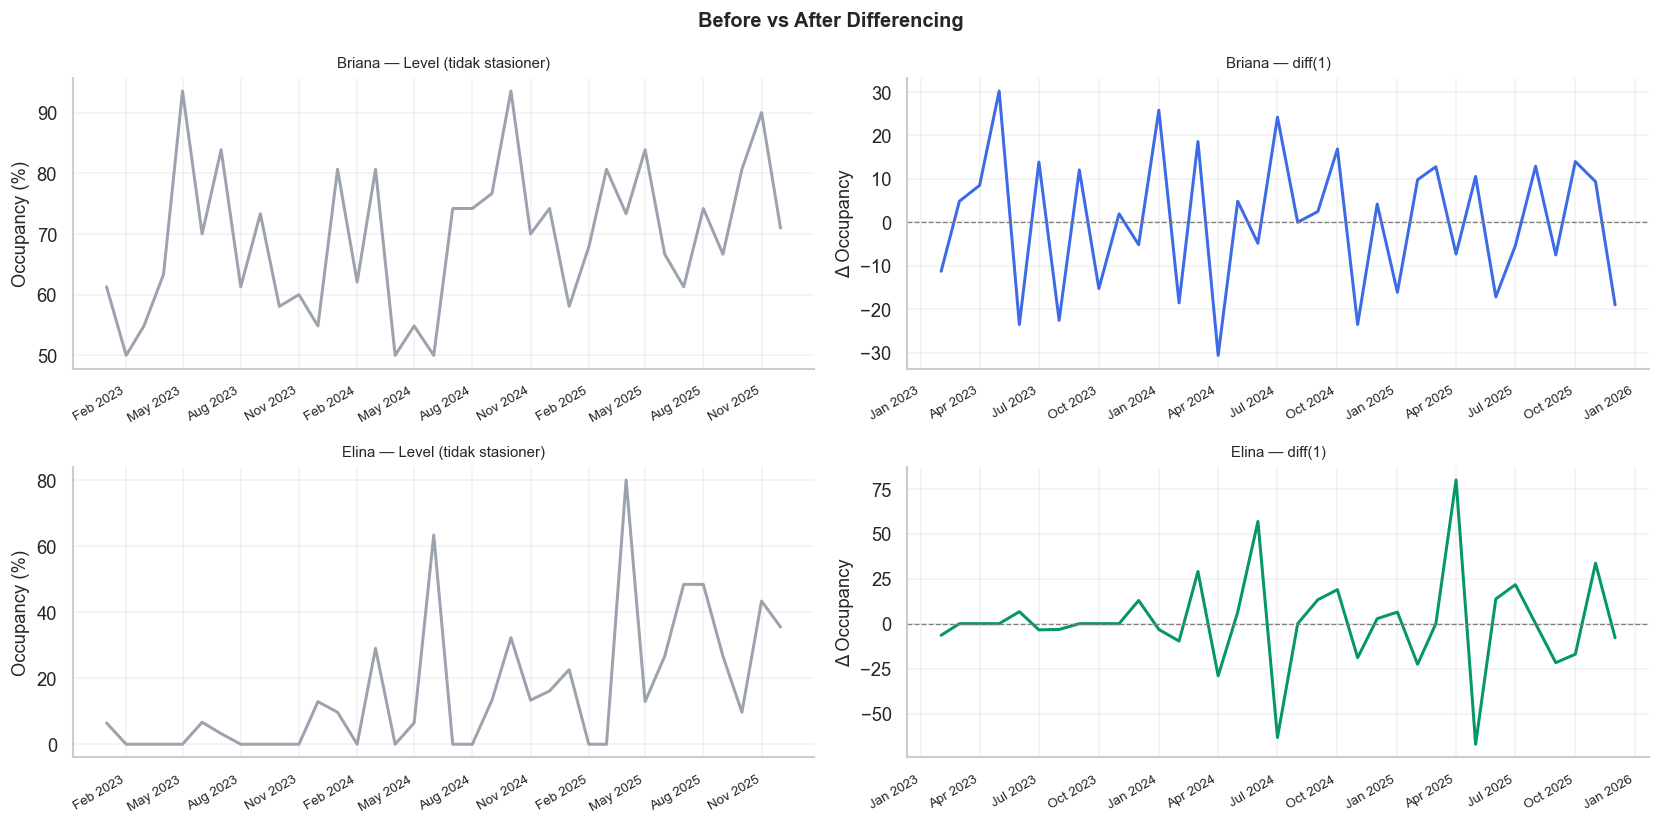

Uji ADF selesai.


In [ ]:
def adf_check(series, alpha=0.05):
    res = adfuller(series.dropna(), autolag='AIC')
    return res[1] < alpha, round(res[1], 4), round(res[0], 4)

clean_occ_stationary = {}
villa_d              = {}
adf_results          = []

print('UJI STASIONERITAS — AUGMENTED DICKEY-FULLER (alpha = 5%)')
print('=' * 90)

for villa, series in clean_occ_final.items():
    monthly = series.resample('MS').mean().dropna()
    title   = villa.replace('_villas', '').title()
    area    = VILLA_CONFIG[villa]['area'].title()

    stat0, p0, adf0 = adf_check(monthly)

    if stat0:
        d_used       = 0
        series_final = monthly
        p1           = '-'
        note         = 'Stasioner (d=0)'
    else:
        diff1        = monthly.diff().dropna()
        stat1, p1, _ = adf_check(diff1)
        d_used       = 1   # dibatasi maksimum d=1, tidak lanjut ke d=2
        series_final = diff1
        note = (f'Diff(1) -> stasioner (p={p1})' if stat1
                else f'Diff(1) belum sempurna (p={p1}), d=1 tetap dipakai')

    # d dipaksa tidak lebih dari 1
    d_used = min(d_used, 1)

    clean_occ_stationary[villa] = series_final
    villa_d[villa]              = d_used

    adf_results.append({
        'Villa'       : title,
        'Area'        : area,
        'N (bln)'     : len(monthly),
        'ADF (level)' : adf0,
        'p (level)'   : p0,
        'p (diff1)'   : p1,
        'd dipakai'   : d_used,
        'Keterangan'  : note,
    })

adf_df = pd.DataFrame(adf_results)
print(adf_df[['Villa','Area','N (bln)','ADF (level)','p (level)','p (diff1)',
               'd dipakai','Keterangan']].to_string(index=False))
print(f'\nvilla_d = {villa_d}')

# Plot before/after untuk villa yang di-differencing
villa_diffed = [v for v, d in villa_d.items() if d > 0]
if villa_diffed:
    fig, axes = plt.subplots(len(villa_diffed), 2,
                             figsize=(14, 3.5 * len(villa_diffed)))
    if len(villa_diffed) == 1:
        axes = [axes]
    for ax_row, villa in zip(axes, villa_diffed):
        color   = VILLA_CONFIG[villa]['color']
        title   = villa.replace('_villas','').title()
        monthly = clean_occ_final[villa].resample('MS').mean().dropna()
        stat_s  = clean_occ_stationary[villa]
        ax_row[0].plot(monthly.index, monthly.values, color='#9ca3af', lw=1.8)
        ax_row[0].set_title(f'{title} — Level (tidak stasioner)', fontsize=9)
        ax_row[0].set_ylabel('Occupancy (%)')
        ax_row[1].plot(stat_s.index, stat_s.values, color=color, lw=1.8)
        ax_row[1].axhline(0, color='gray', ls='--', lw=0.8)
        ax_row[1].set_title(f'{title} — diff(1)', fontsize=9)
        ax_row[1].set_ylabel('Δ Occupancy')
        for ax in ax_row:
            ax.grid(alpha=0.25); ax.spines[['top','right']].set_visible(False)
            ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
            ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
            plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)
    plt.suptitle('Before vs After Differencing', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('adf_before_after.png', dpi=150, bbox_inches='tight')
    plt.show()
print('Uji ADF selesai.')

## ACF & PACF — Identifikasi Order SARIMA

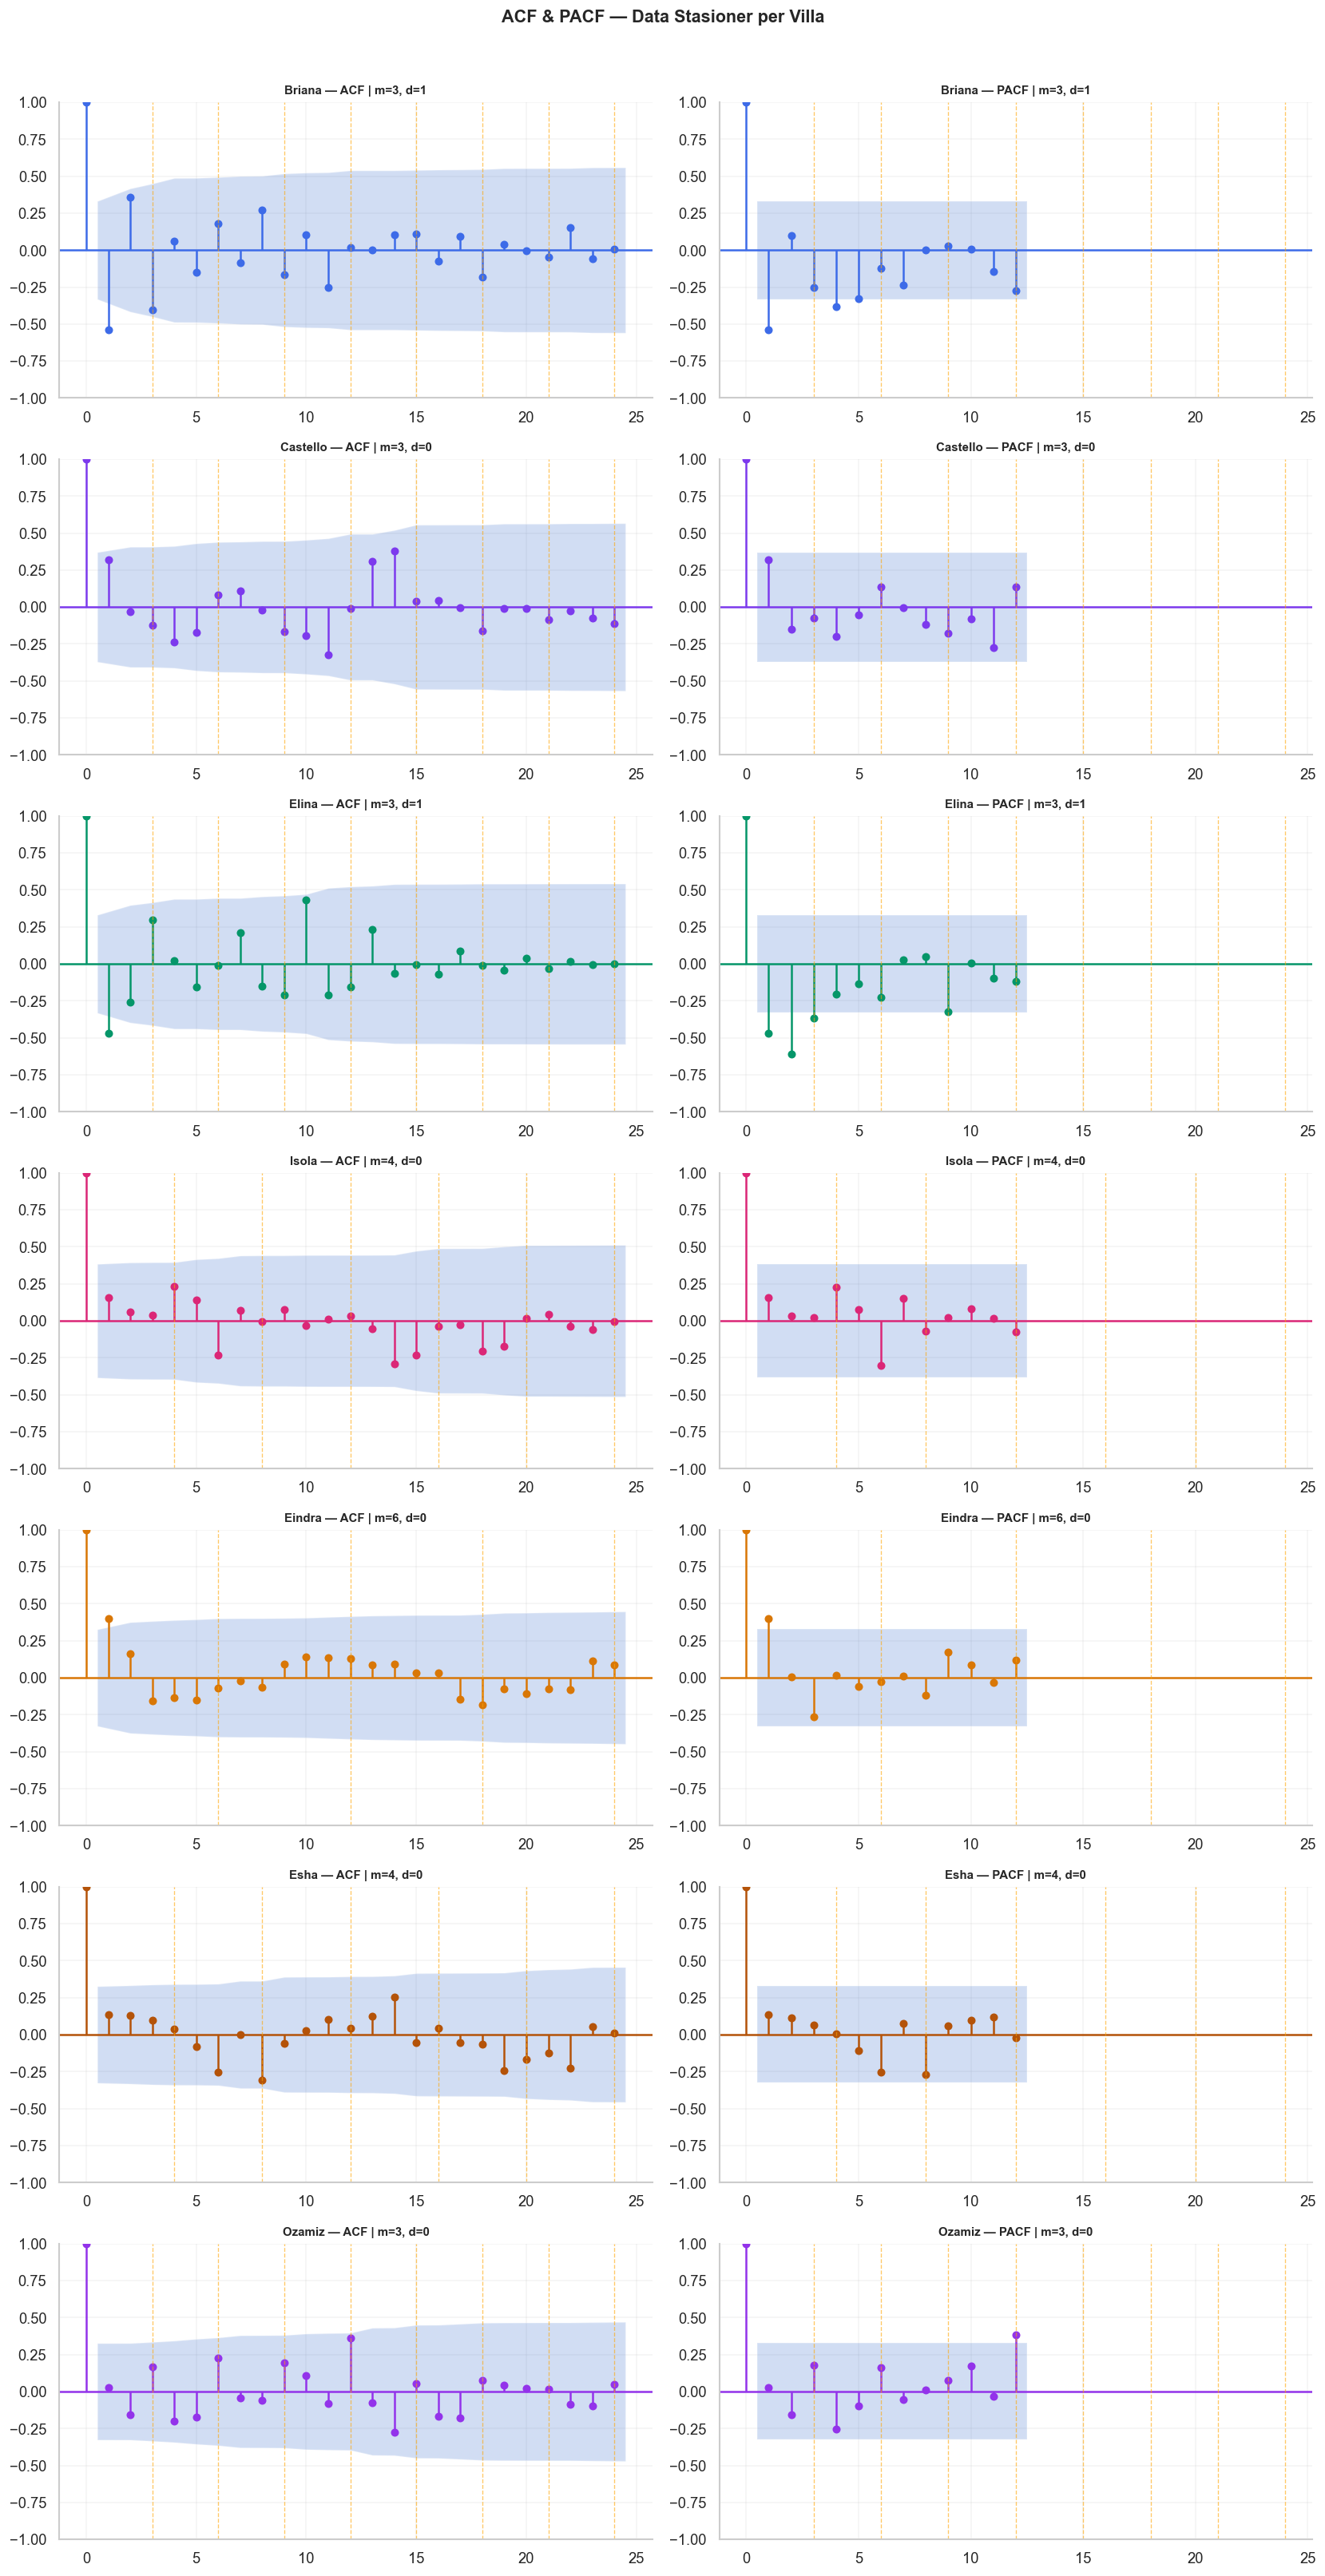

In [ ]:
n_villas = len(clean_occ_stationary)
fig, axes = plt.subplots(n_villas, 2, figsize=(14, 3.8 * n_villas))
if n_villas == 1:
    axes = [axes]

fig.suptitle('ACF & PACF — Data Stasioner per Villa',
             fontsize=13, fontweight='bold', y=1.01)

for ax_row, (villa, series) in zip(axes, clean_occ_stationary.items()):
    title  = villa.replace('_villas','').title()
    color  = VILLA_CONFIG[villa]['color']
    m_val  = villa_m[villa]
    d_val  = villa_d[villa]
    n      = len(series.dropna())

    max_lag_acf  = min(24, n - 1)
    max_lag_pacf = min(int(n / 2) - 1, 12)

    plot_acf(series.dropna(), lags=max_lag_acf, ax=ax_row[0],
             color=color, vlines_kwargs={'colors': color}, alpha=0.05, zero=True, title='')
    ax_row[0].set_title(f'{title} — ACF | m={m_val}, d={d_val}', fontsize=9, fontweight='bold')

    plot_pacf(series.dropna(), lags=max_lag_pacf, ax=ax_row[1],
              color=color, vlines_kwargs={'colors': color}, alpha=0.05,
              zero=True, method='ywm', title='')
    ax_row[1].set_title(f'{title} — PACF | m={m_val}, d={d_val}', fontsize=9, fontweight='bold')

    for ax in ax_row:
        for lag_mark in range(m_val, max_lag_acf + 1, m_val):
            ax.axvline(lag_mark, color='orange', lw=0.8, ls='--', alpha=0.6)
        ax.grid(alpha=0.2); ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('acf_pacf_stationary.png', dpi=150, bbox_inches='tight')
plt.show()

## Seleksi Model SARIMA - Minimum BIC & Uji L-jung Box

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import itertools, time

# ============================================================
# KONFIGURASI GRID SEARCH
# ============================================================
p_range = [0, 1, 2]
q_range = [0, 1, 2]
P_range = [0, 1, 2]
Q_range = [0, 1, 2]
D_range = [0, 1]        # <- D sekarang DIUJI, bukan dipaksa 1
combos  = list(itertools.product(p_range, q_range, P_range, Q_range, D_range))

MIN_OBS_PER_PARAM = 3   # aturan minimal: n_bln >= 3 x jumlah parameter model

grid_rows = []

print('GRID SEARCH SARIMA')
print(f'Total kombinasi per villa: {len(combos)} (p,q,P,Q dalam [0,1,2], D dalam [0,1])')
print('d dan m dikunci dari ADF & Periodogram. D diuji lewat grid (BIC + Ljung-Box).')
print(f'Kandidat dengan n_bln < {MIN_OBS_PER_PARAM} x n_params akan ditandai overfit-risk.')
print('=' * 75)

for villa, series in clean_occ_final.items():
    title   = villa.replace('_villas','').title()
    area    = VILLA_CONFIG[villa]['area'].title()
    d_val   = villa_d[villa]
    m_val   = villa_m[villa]
    monthly = series.resample('MS').mean().dropna()
    n_bln   = len(monthly)
    max_m   = n_bln // 4

    dasar_d = (
        f'ADF: data sudah stasioner -> d=0 (tidak perlu differencing)'
        if d_val == 0 else
        f'ADF: data tidak stasioner -> diff(1) membuat stasioner -> d=1 (d di-cap maks 1)'
    )

    metode_m = 'periodogram'
    if 'm_det_results' in dir():
        for r in m_det_results:
            if r['Villa'].lower() == title.lower():
                metode_m = r['Metode']
                break
    dasar_m = (
        f'Periodogram+ACF: m={m_val} terdeteksi sebagai frekuensi dominan '
        f'(metode={metode_m}, MAX_M={max_m} dari n={n_bln} bln)'
    )

    print(f'\n[{title}] | d={d_val} m={m_val} | n={n_bln} bln')

    success, failed = 0, 0
    t0 = time.time()

    for p, q, P, Q, D in combos:
        order          = (p, d_val, q)
        seasonal_order = (P, D, Q, m_val)
        n_params       = p + q + P + Q + (1 if d_val > 0 else 0) + (1 if D > 0 else 0)

        try:
            mod_full = SARIMAX(monthly, order=order, seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False)

            lb_lag = min(10, n_bln // 2 - 1)
            lb_result = acorr_ljungbox(mod_full.resid, lags=[lb_lag], return_df=True)
            lb_pvalue = round(lb_result['lb_pvalue'].iloc[0], 4)
            lb_status = 'Residual White Noise' if lb_pvalue > 0.05 else 'Residual Tidak White Noise'

            overfit_risk = n_bln < MIN_OBS_PER_PARAM * max(n_params, 1)

            grid_rows.append({
                'Vila'          : title,
                'Area'          : area,
                'Order'         : str(order),
                'Seasonal Order': str(seasonal_order),
                'N_Params'      : n_params,
                'N_bln'         : n_bln,
                'Overfit_Risk'  : overfit_risk,
                'AIC'           : round(mod_full.aic, 2),
                'BIC'           : round(mod_full.bic, 2),
                'LB_lag'        : lb_lag,
                'LB_pvalue'     : lb_pvalue,
                'LB_Status'     : lb_status,
                'Step1_Dasar_d' : dasar_d,
                'Step2_Dasar_m' : dasar_m,
            })
            success += 1
        except Exception:
            failed += 1

    print(f'  {success} berhasil | {failed} skip | {round(time.time()-t0,1)}s')

    villa_df = pd.DataFrame([r for r in grid_rows if r['Vila'] == title])
    if not villa_df.empty:
        print(f'  Top 5 BIC (semua kandidat, termasuk yang overfit-risk/gagal LB):')
        print(villa_df.nsmallest(5, 'BIC')[
            ['Order','Seasonal Order','BIC','LB_pvalue','LB_Status','Overfit_Risk']
        ].to_string(index=False))


# ============================================================
# SELEKSI MODEL — bertingkat, jujur soal status LB & overfit
# ============================================================
grid_df = pd.DataFrame(grid_rows).sort_values(['Vila', 'BIC']).reset_index(drop=True)

def select_best(df):
    """
    Prioritas seleksi (dari paling ketat ke paling longgar):
    1. Lolos Ljung-Box DAN tidak overfit-risk -> pilih BIC terkecil di sini
    2. Kalau kosong: lolos Ljung-Box saja (abaikan overfit-risk) -> BIC terkecil
    3. Kalau masih kosong: BIC terkecil dari semua kandidat (fallback penuh)
    Setiap tingkat diberi label transparan di Step3_Status.
    """
    df = df.copy()
    df['Rank_BIC']    = 9999
    df['Step3_Status'] = 'Model Lainnya'

    tier1 = df[(df['LB_Status'] == 'Residual White Noise') & (~df['Overfit_Risk'])]
    tier2 = df[(df['LB_Status'] == 'Residual White Noise') & (df['Overfit_Risk'])]

    if not tier1.empty:
        best_idx = tier1['BIC'].idxmin()
        df.loc[best_idx, 'Step3_Status'] = 'Terpilih (BIC terkecil, Lolos Ljung-Box, sampel memadai)'
    elif not tier2.empty:
        best_idx = tier2['BIC'].idxmin()
        df.loc[best_idx, 'Step3_Status'] = 'Terpilih (BIC terkecil, Lolos Ljung-Box, TAPI sampel kecil/overfit-risk)'
    else:
        best_idx = df['BIC'].idxmin()
        df.loc[best_idx, 'Step3_Status'] = 'Terpilih (BIC terkecil, TIDAK ADA kandidat lolos Ljung-Box — limitasi metodologis)'

    df.loc[best_idx, 'Rank_BIC'] = 1
    others = df.index != best_idx
    df.loc[others, 'Rank_BIC'] = df.loc[others, 'BIC'].rank(method='first', ascending=True).astype(int) + 1
    return df

grid_df = grid_df.groupby('Vila', group_keys=False).apply(select_best)

def build_step_seleksi(row):
    if row['Rank_BIC'] != 1:
        return ''
    return (
        f"[Step 1] Stasioneritas: {row['Step1_Dasar_d']}. "
        f"[Step 2] Musiman: {row['Step2_Dasar_m']}. "
        f"[Step 3] Grid search {len(combos)} kombinasi (p,q,P,Q,D) -> model ini BIC={row['BIC']}, "
        f"AIC={row['AIC']}, n_params={row['N_Params']} dari n={row['N_bln']} bln. "
        f"[Step 4] Uji Ljung-Box: p-value={row['LB_pvalue']} pada lag {row['LB_lag']} -> {row['LB_Status']}. "
        f"[Status seleksi] {row['Step3_Status']}."
    )

grid_df['Step4_Narasi_Seleksi'] = grid_df.apply(build_step_seleksi, axis=1)

cols_normal = [
    'Vila', 'Area', 'Order', 'Seasonal Order', 'N_Params', 'N_bln', 'Overfit_Risk',
    'AIC', 'BIC', 'LB_lag', 'LB_pvalue', 'LB_Status', 'Rank_BIC'
]
grid_df[cols_normal].to_csv('sarima_grid_search.csv', index=False)

cols_penjelasan = cols_normal + [
    'Step1_Dasar_d', 'Step2_Dasar_m', 'Step3_Status', 'Step4_Narasi_Seleksi'
]
grid_df[cols_penjelasan].to_csv('sarima_grid_search_penjelasan.csv', index=False)

print('\n' + '=' * 75)
print('sarima_grid_search.csv tersimpan (format normal)')
print('sarima_grid_search_penjelasan.csv tersimpan (dengan step penjelasan)')
print('\nRingkasan model terpilih per villa:')
terpilih_df = grid_df[grid_df['Rank_BIC'] == 1][
    ['Vila', 'Order', 'Seasonal Order', 'N_Params', 'N_bln', 'BIC', 'LB_pvalue', 'LB_Status', 'Step3_Status']
]
display(terpilih_df.reset_index(drop=True))

GRID SEARCH SARIMA
Total kombinasi per villa: 162 (p,q,P,Q dalam [0,1,2], D dalam [0,1])
d dan m dikunci dari ADF & Periodogram. D diuji lewat grid (BIC + Ljung-Box).
Kandidat dengan n_bln < 3 x n_params akan ditandai overfit-risk.

[Briana] | d=1 m=3 | n=36 bln
  162 berhasil | 0 skip | 6.7s
  Top 5 BIC (semua kandidat, termasuk yang overfit-risk/gagal LB):
    Order Seasonal Order    BIC  LB_pvalue                  LB_Status  Overfit_Risk
(2, 1, 2)   (2, 1, 2, 3) 194.08       0.02 Residual Tidak White Noise         False
(2, 1, 1)   (2, 1, 0, 3) 196.39       0.00 Residual Tidak White Noise         False
(2, 1, 2)   (1, 1, 2, 3) 197.79       0.23       Residual White Noise         False
(2, 1, 2)   (2, 1, 0, 3) 198.54       0.01 Residual Tidak White Noise         False
(0, 1, 2)   (0, 1, 2, 3) 198.62       0.00 Residual Tidak White Noise         False

[Castello] | d=0 m=3 | n=28 bln
  162 berhasil | 0 skip | 7.0s
  Top 5 BIC (semua kandidat, termasuk yang overfit-risk/gagal LB):
    

,Vila,Order,Seasonal Order,N_Params,N_bln,BIC,LB_pvalue,LB_Status,Step3_Status
0,Briana,"(2, 1, 2)","(1, 1, 2, 3)",9,36,197.79,0.23,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."
1,Castello,"(0, 0, 2)","(0, 1, 2, 3)",5,28,163.17,0.31,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."
2,Eindra,"(2, 0, 2)","(2, 1, 2, 6)",9,36,138.20,0.70,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."
3,Elina,"(0, 1, 2)","(0, 1, 2, 3)",6,36,221.73,0.51,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."
4,Esha,"(2, 0, 2)","(2, 1, 1, 4)",8,36,194.80,0.10,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."
5,Isola,"(2, 0, 1)","(0, 1, 2, 4)",6,26,109.81,0.05,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."
6,Ozamiz,"(0, 0, 2)","(0, 1, 2, 3)",5,36,226.77,0.90,Residual White Noise,"Terpilih (BIC terkecil, Lolos Ljung-Box, sampe..."


In [ ]:
# ============================================================
# BANGUN sarima_models DARI HASIL SELEKSI (grid_df, Rank_BIC == 1)
# ============================================================
TEST_SIZE_MONTHS = 6   # jumlah bulan terakhir dipakai sebagai test set

terpilih_df = grid_df[grid_df['Rank_BIC'] == 1].copy()

sarima_models = {}

print('MEMBANGUN MODEL FINAL PER VILLA (dari hasil seleksi grid search)')
print('=' * 75)

for villa, series in clean_occ_final.items():
    title = villa.replace('_villas', '').title()

    row = terpilih_df[terpilih_df['Vila'] == title]
    if row.empty:
        print(f'  [{title}] Tidak ditemukan di hasil seleksi -> SKIP')
        continue
    row = row.iloc[0]

    order   = eval(row['Order'])            # string '(p, d, q)' -> tuple
    s_order = eval(row['Seasonal Order'])   # string '(P, D, Q, m)' -> tuple

    monthly = series.resample('MS').mean().dropna()
    n_bln   = len(monthly)

    if n_bln <= TEST_SIZE_MONTHS + 6:
        print(f'  [{title}] n_bln={n_bln} terlalu pendek untuk train/test split '
              f'(butuh > {TEST_SIZE_MONTHS + 6}) -> SKIP')
        continue

    train = monthly.iloc[:-TEST_SIZE_MONTHS]
    test  = monthly.iloc[-TEST_SIZE_MONTHS:]

    try:
        model = SARIMAX(train, order=order, seasonal_order=s_order,
                         enforce_stationarity=False,
                         enforce_invertibility=False).fit(disp=False)
    except Exception as e:
        print(f'  [{title}] Fit gagal ({e}) -> SKIP')
        continue

    # forecast di periode test, untuk evaluasi & plotting "Fitted (test)"
    fore_test  = model.get_forecast(steps=len(test))
    pred_mean  = fore_test.predicted_mean.clip(0, 100)
    pred_mean.index = test.index

    # metrik evaluasi sederhana
    mae  = (test - pred_mean).abs().mean()
    rmse = np.sqrt(((test - pred_mean) ** 2).mean())

    sarima_models[villa] = {
        'order'          : order,
        'seasonal_order' : s_order,
        'train'          : train,
        'test'           : test,
        'model'          : model,
        'pred_mean'      : pred_mean,
        'mae'            : round(mae, 2),
        'rmse'           : round(rmse, 2),
    }

    print(f'  [{title}] order={order} seasonal={s_order} | '
          f'train={len(train)} bln, test={len(test)} bln | MAE={mae:.2f} RMSE={rmse:.2f}')

print('=' * 75)
print(f'{len(sarima_models)} villa berhasil dibangun modelnya -> siap untuk cell forecast.')

# ringkasan evaluasi test set
eval_rows = [
    {
        'Villa': villa.replace('_villas','').title(),
        'Order': str(info['order']),
        'Seasonal Order': str(info['seasonal_order']),
        'MAE (test)': info['mae'],
        'RMSE (test)': info['rmse'],
    }
    for villa, info in sarima_models.items()
]
eval_df = pd.DataFrame(eval_rows)
display(eval_df)

MEMBANGUN MODEL FINAL PER VILLA (dari hasil seleksi grid search)
  [Briana] order=(2, 1, 2) seasonal=(1, 1, 2, 3) | train=30 bln, test=6 bln | MAE=10.76 RMSE=12.54
  [Castello] order=(0, 0, 2) seasonal=(0, 1, 2, 3) | train=22 bln, test=6 bln | MAE=15.67 RMSE=21.51
  [Elina] order=(0, 1, 2) seasonal=(0, 1, 2, 3) | train=30 bln, test=6 bln | MAE=20.82 RMSE=27.14
  [Isola] order=(2, 0, 1) seasonal=(0, 1, 2, 4) | train=20 bln, test=6 bln | MAE=41.98 RMSE=46.84
  [Eindra] order=(2, 0, 2) seasonal=(2, 1, 2, 6) | train=30 bln, test=6 bln | MAE=17.55 RMSE=20.13
  [Esha] order=(2, 0, 2) seasonal=(2, 1, 1, 4) | train=30 bln, test=6 bln | MAE=20.53 RMSE=27.34
  [Ozamiz] order=(0, 0, 2) seasonal=(0, 1, 2, 3) | train=30 bln, test=6 bln | MAE=13.80 RMSE=18.73
7 villa berhasil dibangun modelnya -> siap untuk cell forecast.


,Villa,Order,Seasonal Order,MAE (test),RMSE (test)
0,Briana,"(2, 1, 2)","(1, 1, 2, 3)",10.76,12.54
1,Castello,"(0, 0, 2)","(0, 1, 2, 3)",15.67,21.51
2,Elina,"(0, 1, 2)","(0, 1, 2, 3)",20.82,27.14
3,Isola,"(2, 0, 1)","(0, 1, 2, 4)",41.98,46.84
4,Eindra,"(2, 0, 2)","(2, 1, 2, 6)",17.55,20.13
5,Esha,"(2, 0, 2)","(2, 1, 1, 4)",20.53,27.34
6,Ozamiz,"(0, 0, 2)","(0, 1, 2, 3)",13.80,18.73


## Forecast 6 Bulan


[Briana] refit 36 bln -> forecast 6 bln | m=3
   Refit method dipakai: lbfgs

[Castello] refit 28 bln -> forecast 6 bln | m=3
   Refit method dipakai: lbfgs

[Elina] refit 36 bln -> forecast 6 bln | m=3
   Refit method dipakai: lbfgs

[Isola] refit 26 bln -> forecast 6 bln | m=4
   Refit method dipakai: lbfgs

[Eindra] refit 36 bln -> forecast 6 bln | m=6
   Refit method dipakai: lbfgs

[Esha] refit 36 bln -> forecast 6 bln | m=4
   Refit method dipakai: lbfgs

[Ozamiz] refit 36 bln -> forecast 6 bln | m=3
   Refit method dipakai: lbfgs


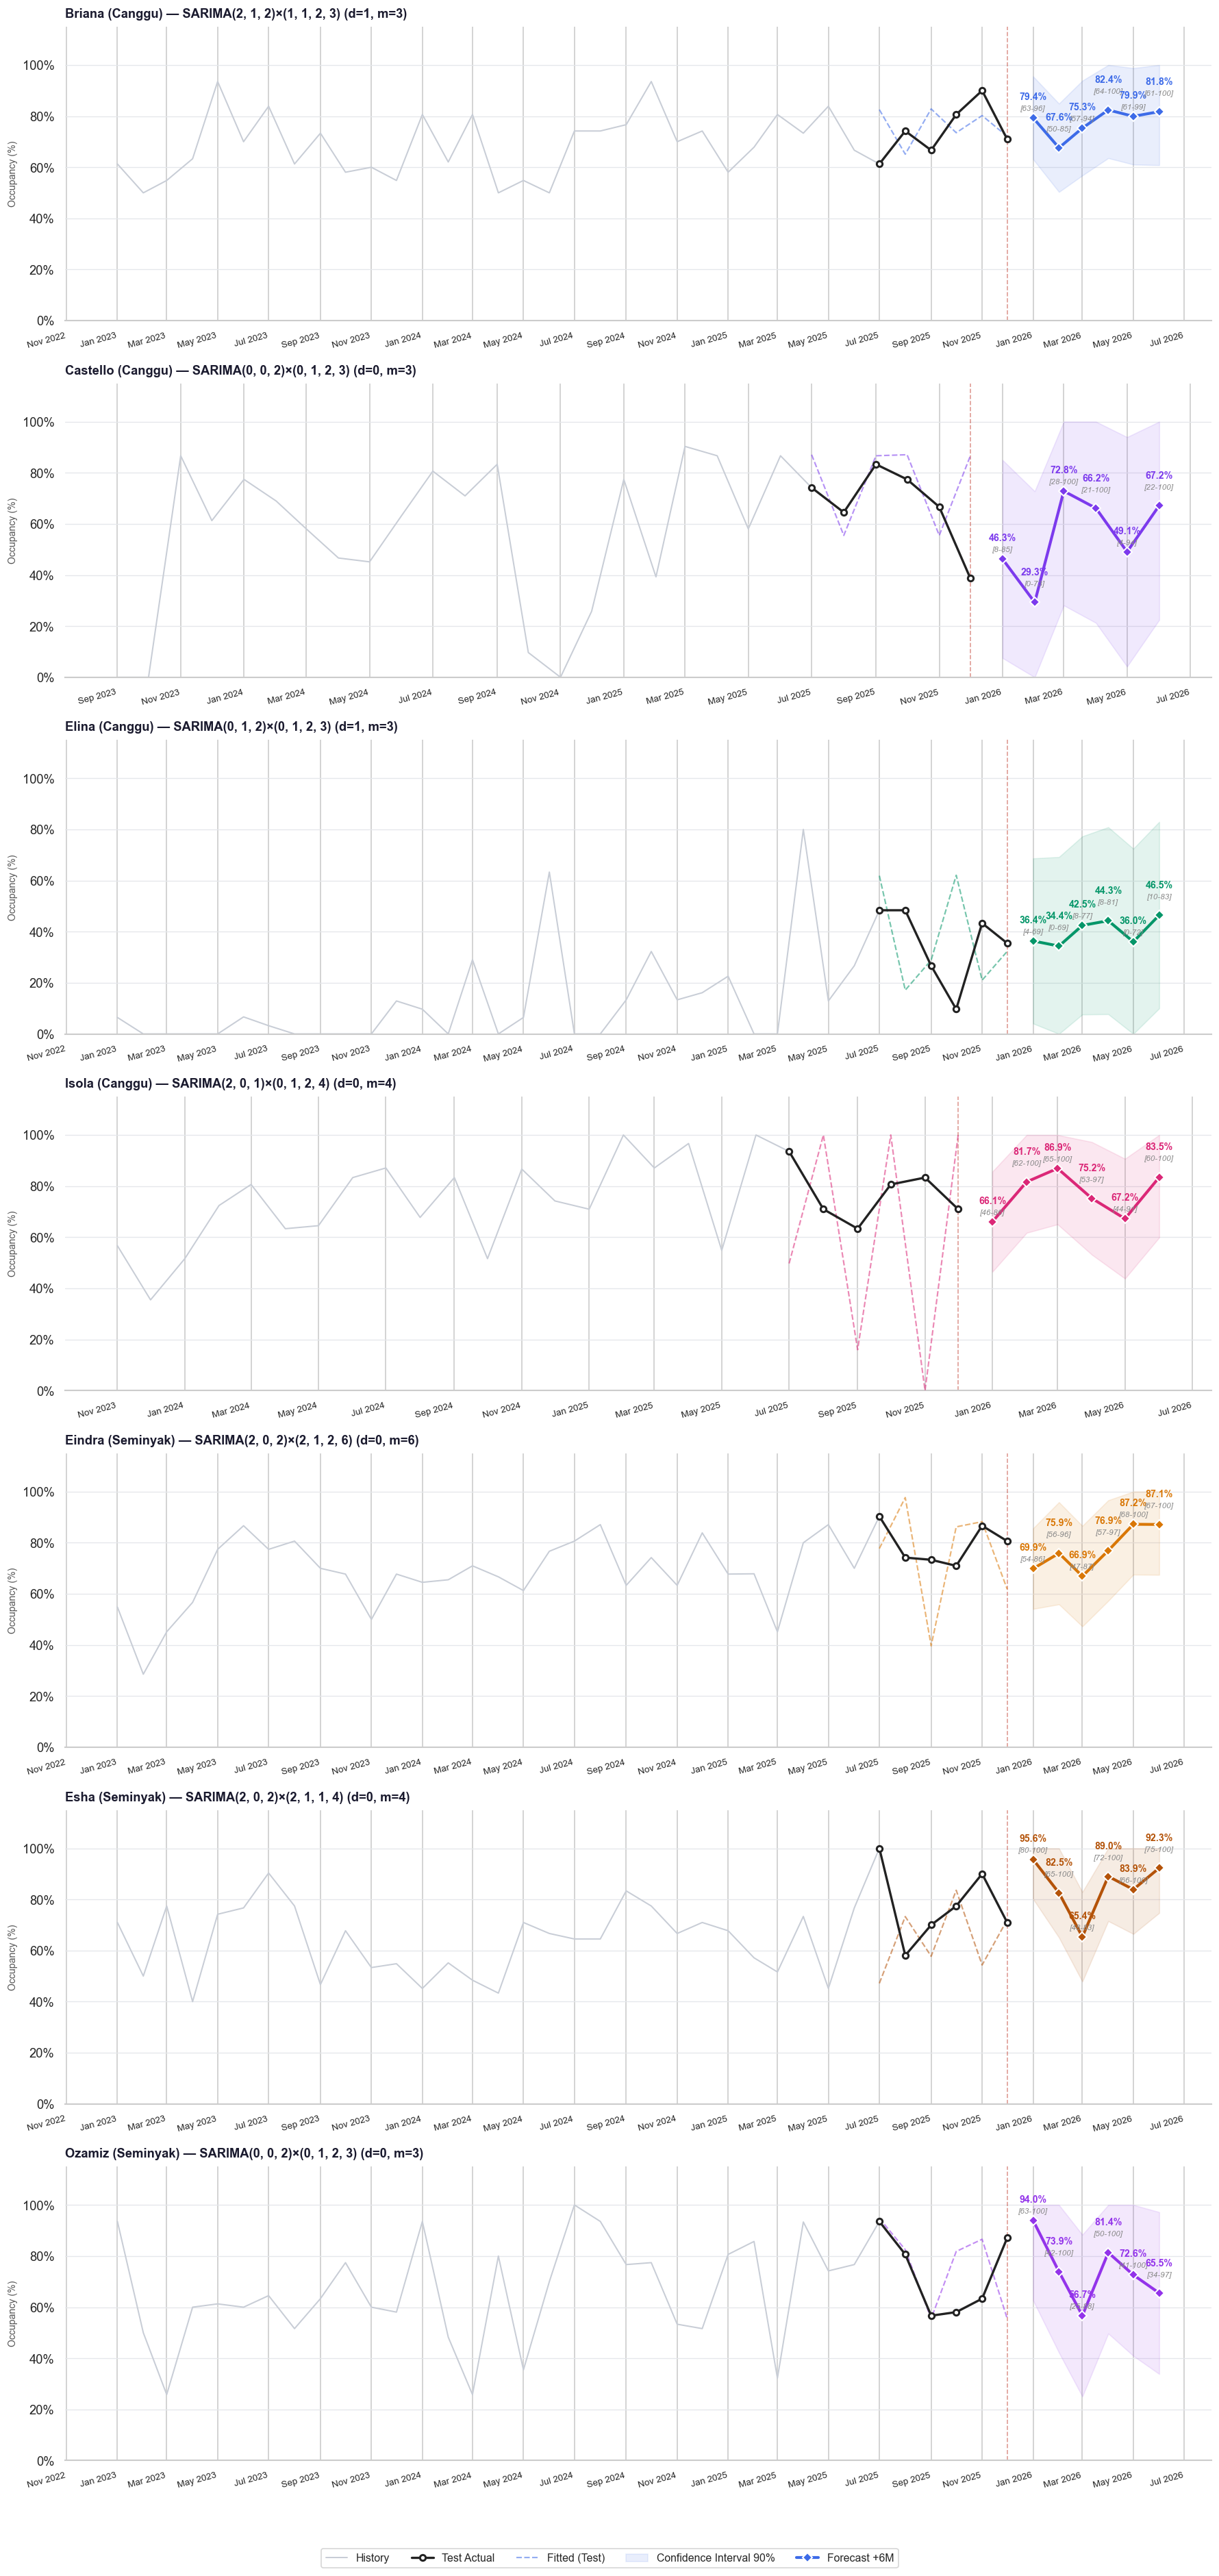

FORECAST OCCUPANCY +6 BULAN VIRTICAL


Area  Forecast (%)  Lower CI 90%  Upper CI 90%  \
Villa    Bulan                                                          
Briana   Jan 2026    Canggu         79.40         63.20         95.60   
         Feb 2026    Canggu         67.60         50.30         84.90   
         Mar 2026    Canggu         75.30         56.80         93.90   
         Apr 2026    Canggu         82.40         63.60        100.00   
         May 2026    Canggu         79.90         61.10         98.80   
         Jun 2026    Canggu         81.80         60.80        100.00   
Castello Jan 2026    Canggu         46.30          7.50         85.00   
         Feb 2026    Canggu         29.30          0.00         72.80   
         Mar 2026    Canggu         72.80         28.10        100.00   
         Apr 2026    Canggu         66.20         21.30        100.00   
         May 2026    Canggu         49.10          4.20         94.00   
         Jun 2026    Canggu         67.20         22.50        100.00   
Elina    Jan 2026    Canggu         36.40          4.10         68.70   
         Feb 2026    Canggu         34.40          0.00         69.20   
         Mar 2026    Canggu         42.50          7.60         77.30   
         Apr 2026    Canggu         44.30          7.70         80.90   
         May 2026    Canggu         36.00          0.00         72.50   
         Jun 2026    Canggu         46.50         10.00         83.00   
Isola    Jan 2026    Canggu         66.10         46.50         85.70   
         Feb 2026    Canggu         81.70         61.70        100.00   
         Mar 2026    Canggu         86.90         65.00        100.00   
         Apr 2026    Canggu         75.20         53.20         97.20   
         May 2026    Canggu         67.20         43.80         90.70   
         Jun 2026    Canggu         83.50         59.90        100.00   
Eindra   Jan 2026  Seminyak         69.90         54.10         85.60   
         Feb 2026  Seminyak         75.90         55.90         95.90   
         Mar 2026  Seminyak         66.90         47.30         86.60   
         Apr 2026  Seminyak         76.90         57.30         96.60   
         May 2026  Seminyak         87.20         67.50        100.00   
         Jun 2026  Seminyak         87.10         67.40        100.00   
Esha     Jan 2026  Seminyak         95.60         80.20        100.00   
         Feb 2026  Seminyak         82.50         65.10        100.00   
         Mar 2026  Seminyak         65.40         47.90         82.90   
         Apr 2026  Seminyak         89.00         71.50        100.00   
         May 2026  Seminyak         83.90         66.50        100.00   
         Jun 2026  Seminyak         92.30         74.70        100.00   
Ozamiz   Jan 2026  Seminyak         94.00         62.60        100.00   
         Feb 2026  Seminyak         73.90         42.20        100.00   
         Mar 2026  Seminyak         56.70         25.00         88.30   
         Apr 2026  Seminyak         81.40         49.70        100.00   
         May 2026  Seminyak         72.60         40.90        100.00   
         Jun 2026  Seminyak         65.50         33.80         97.20   

                   Rentang CI  Flat?  
Villa    Bulan                        
Briana   Jan 2026       32.40  Tidak  
         Feb 2026       34.60  Tidak  
         Mar 2026       37.10  Tidak  
         Apr 2026       36.40  Tidak  
         May 2026       37.70  Tidak  
         Jun 2026       39.20  Tidak  
Castello Jan 2026       77.50  Tidak  
         Feb 2026       72.80  Tidak  
         Mar 2026       71.90  Tidak  
         Apr 2026       78.70  Tidak  
         May 2026       89.80  Tidak  
         Jun 2026       77.50  Tidak  
Elina    Jan 2026       64.60  Tidak  
         Feb 2026       69.20  Tidak  
         Mar 2026       69.70  Tidak  
         Apr 2026       73.20  Tidak  
         May 2026       72.50  Tidak  
         Jun 2026       73.00  Tidak  
Isola    Jan 2026       39.20 


forecast_occupancy_2026.csv berhasil diexport.


In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX

FORECAST_STEPS  = 6
FLAT_STD_THRESH = 1.5

forecast_rows = []
flat_villas   = []

def robust_refit(data, order, s_order, start_params=None):
    """
    Coba beberapa kombinasi optimizer/maxiter/start_params supaya refit
    lebih tahan gagal konvergen.
    """
    attempts = [
        dict(method='lbfgs',  maxiter=200, start_params=start_params),
        dict(method='powell', maxiter=200, start_params=start_params),
        dict(method='nm',     maxiter=500, start_params=start_params),
    ]
    for cfg in attempts:
        try:
            m = SARIMAX(data, order=order, seasonal_order=s_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False).fit(disp=False, **cfg)
            if m.mle_retvals.get('converged', None) is not False:
                return m, cfg['method']
        except Exception:
            continue
    return None, None

# ==========================================
# PRE-PROCESSING & KALKULASI FORECAST
# ==========================================
valid_plots_data = []

for villa, info in sarima_models.items():
    order   = info['order']
    s_order = info['seasonal_order']
    monthly = pd.concat([info['train'], info['test']])
    d       = order[1]
    m_used  = s_order[3]
    color   = VILLA_CONFIG[villa]['color']
    title   = villa.replace('_villas','').title()
    area    = VILLA_CONFIG[villa]['area'].title()

    print(f'\n[{title}] refit {len(monthly)} bln -> forecast {FORECAST_STEPS} bln | m={m_used}')

    try:
        n_expected_params = (order[0] + order[2] + s_order[0] + s_order[2]
                             + (1 if order[1] > 0 else 0)
                             + (1 if s_order[1] > 0 else 0) + 1)
        sp = None
        try:
            if len(info['model'].params) == n_expected_params:
                sp = info['model'].params.values
        except Exception:
            sp = None

        model_full, used_method = robust_refit(monthly, order, s_order, start_params=sp)
        if model_full is None:
            model_full = SARIMAX(monthly, order=order, seasonal_order=s_order,
                                 enforce_stationarity=False,
                                 enforce_invertibility=False).fit(disp=False)
            used_method = 'lbfgs-default (gagal konvergen)'
        print(f'   Refit method dipakai: {used_method}')
    except Exception as e:
        print(f'   [WARNING] Refit gagal ({e}), pakai model training sebelumnya.')
        model_full = info['model']

    converged = model_full.mle_retvals.get('converged', None)
    
    fore_obj  = model_full.get_forecast(steps=FORECAST_STEPS)
    fore_mean = fore_obj.predicted_mean.clip(0, 100)
    fore_ci   = fore_obj.conf_int(alpha=0.10).clip(0, 100)
    fore_std  = fore_mean.std()

    ci_has_nan = fore_ci.isna().any().any()
    model_invalid = (converged is False) or ci_has_nan

    if model_invalid:
        print(f'   -> Coba fallback ke model training awal...')
        try:
            fallback_model = info['model']
            fore_obj_fb  = fallback_model.get_forecast(steps=FORECAST_STEPS)
            fore_mean_fb = fore_obj_fb.predicted_mean.clip(0, 100)
            fore_ci_fb   = fore_obj_fb.conf_int(alpha=0.10).clip(0, 100)
            fb_converged = fallback_model.mle_retvals.get('converged', None)
            fb_ci_nan    = fore_ci_fb.isna().any().any()
            if fb_converged is not False and not fb_ci_nan:
                model_full, fore_mean, fore_ci = fallback_model, fore_mean_fb, fore_ci_fb
                fore_std = fore_mean.std()
                model_invalid = False
                print(f'   -> Fallback berhasil.')
        except Exception as e:
            print(f'   -> Fallback gagal: {e}')

    used_s_order = s_order

    if not model_invalid and fore_std < FLAT_STD_THRESH:
        print(f'   Flat (std={fore_std:.2f}%) -> retry seasonal...')
        best_aic = model_full.aic; best_model = model_full
        best_fore = fore_mean; best_ci = fore_ci; best_sorder = s_order

        for s_cand in [(1,0,0,m_used),(0,0,1,m_used),(1,0,1,m_used)]:
            try:
                mc = SARIMAX(monthly, order=(order[0], d, order[2]), seasonal_order=s_cand,
                             enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                if mc.mle_retvals.get('converged', None) is False: continue
                fc = mc.get_forecast(steps=FORECAST_STEPS)
                fm = fc.predicted_mean.clip(0, 100)
                fi = fc.conf_int(alpha=0.10).clip(0, 100)
                if fi.isna().any().any(): continue
                
                std_c = fm.std()
                if std_c > FLAT_STD_THRESH and mc.aic < best_aic + 10:
                    best_aic = mc.aic; best_model = mc
                    best_fore = fm; best_ci = fi; best_sorder = s_cand
            except Exception:
                continue

        model_full = best_model; used_s_order = best_sorder
        fore_mean = best_fore; fore_ci = best_ci; fore_std = fore_mean.std()
        if fore_std < FLAT_STD_THRESH:
            flat_villas.append(title)

    is_flat = fore_std < FLAT_STD_THRESH

    if model_invalid:
        print(f'   [SKIP PLOT] {title}: model tidak valid.')
        continue

    # Simpan hasil ke baris dataframe
    for date, val, lo, hi in zip(fore_mean.index, fore_mean.values, fore_ci.iloc[:,0].values, fore_ci.iloc[:,1].values):
        forecast_rows.append({
            'Villa': title, 'Area': area, 'Bulan': date.strftime('%b %Y'),
            'Forecast (%)': round(val, 1), 'Lower CI 90%': round(lo, 1),
            'Upper CI 90%': round(hi, 1), 'Rentang CI': round(hi - lo, 1), 'Flat?': 'Ya' if is_flat else 'Tidak'
        })

    # Simpan data visualisasi untuk plotting terpusat
    valid_plots_data.append({
        'title': title, 'area': area, 'monthly': monthly, 'info': info,
        'fore_ci': fore_ci, 'fore_mean': fore_mean, 'is_flat': is_flat,
        'color': color, 'order': order, 'used_s_order': used_s_order, 'd': d, 'm_used': m_used
    })

# ==========================================
# PROSES PLOTTING GABUNGAN (1 KOLOM VERTIKAL)
# ==========================================
n_plots = len(valid_plots_data)
n_cols = 1  # Mengunci susunan menjadi satu baris lurus ke bawah
n_rows = n_plots

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4.5 * n_rows), sharey=False)

# Pastikan axes berupa array meskipun hanya ada 1 plot
if n_rows == 1:
    axes = [axes]

for idx, p in enumerate(valid_plots_data):
    ax = axes[idx]
    fore_color = '#E24B4A' if p['is_flat'] else p['color']
    
    # Plot data historis dan aktual test
    ax.plot(p['monthly'].index, p['monthly'].values, color='#c8cdd6', lw=1.2, label='History')
    ax.plot(p['info']['test'].index, p['info']['test'].values, color='#222', lw=2,
            marker='o', ms=5, markerfacecolor='white', markeredgewidth=1.8, zorder=4, label='Test Actual')
    ax.plot(p['info']['pred_mean'].index, p['info']['pred_mean'].values,
            color=p['color'], lw=1.3, ls='--', alpha=0.55, zorder=3, label='Fitted (Test)')
    
    # Plot forecast & confidence interval
    ax.fill_between(p['fore_ci'].index, p['fore_ci'].iloc[:,0], p['fore_ci'].iloc[:,1],
                    color=fore_color, alpha=0.11, zorder=2, label='Confidence Interval 90%')
    ax.plot(p['fore_mean'].index, p['fore_mean'].values, color=fore_color, lw=2.5,
            marker='D', ms=6, markerfacecolor=fore_color, markeredgecolor='white', markeredgewidth=1.2,
            zorder=5, label=f'Forecast +{FORECAST_STEPS}M')

    # Data Annotations (Angka Forecast & Interval)
    for i, (dt, val, lo, hi) in enumerate(zip(p['fore_mean'].index, p['fore_mean'].values,
                                             p['fore_ci'].iloc[:,0].values, p['fore_ci'].iloc[:,1].values)):
        base_off = 14 if i % 2 == 0 else 22
        ax.annotate(f'{val:.1f}%', xy=(dt, val), xytext=(0, base_off),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=8.5, fontweight='bold', color=fore_color, zorder=6)
        ax.annotate(f'[{lo:.0f}-{hi:.0f}]', xy=(dt, val), xytext=(0, base_off - 9),
                    textcoords='offset points', ha='center', va='bottom',
                    fontsize=7, color='#888', style='italic', zorder=6)

    # Batas Garis Merah Penanda Mulai Forecast
    ax.axvline(p['monthly'].index[-1], color='#c0392b', ls='--', lw=1.0, alpha=0.5)
    
    # Styling Axis & Judul Subplot
    ax.set_title(f"{p['title']} ({p['area']}) — SARIMA{p['order']}×{p['used_s_order']} (d={p['d']}, m={p['m_used']})",
                 fontsize=11, fontweight='bold', loc='left', color='#1a1a2e', pad=8)
    ax.set_ylabel('Occupancy (%)', fontsize=8.5, color='#555')
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%g%%'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=15, ha='right', fontsize=8)
    ax.grid(axis='y', color='#e5e7eb', lw=0.8)
    ax.spines[['top','right','left']].set_visible(False)

# Pengaturan Legenda Tunggal Terpusat di Paling Bawah
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.015), ncol=5, fontsize=9.5)

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('forecast_2026_vertical_all.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)

# ==========================================
# EXPORT DATA & SUMMARY DIAGNOSTIK
# ==========================================
forecast_df = pd.DataFrame(forecast_rows)
print('=' * 75)
print(f'FORECAST OCCUPANCY +{FORECAST_STEPS} BULAN VIRTICAL')
print('=' * 75)
display(forecast_df.set_index(['Villa','Bulan']))
forecast_df.to_csv('forecast_occupancy_2026.csv', index=False)
print('\nforecast_occupancy_2026.csv berhasil diexport.')

## Evaluasi Model — RMSE & MAPE

In [ ]:
# ============================================================
# METRIK TAMBAHAN: sMAPE & MASE (lebih tahan utk actual mendekati 0)
# ============================================================
# Jalankan SETELAH cell metrik RMSE/MAPE sebelumnya (butuh sarima_models & metric_df)

metric_rows_v2 = []

for villa, info in sarima_models.items():
    title = villa.replace('_villas', '').title()
    train = info['train']
    test  = info['test']
    pred  = info['pred_mean'].reindex(test.index)

    resid = test - pred

    rmse = np.sqrt((resid ** 2).mean())
    mae  = resid.abs().mean()

    # ---- sMAPE: dibatasi 0-200%, jauh lebih stabil saat actual ~0 ----
    denom = (test.abs() + pred.abs())
    smape_terms = np.where(denom > 1e-6, resid.abs() / denom, 0)
    smape = smape_terms.mean() * 100

    # ---- MASE: error model dibagi error naive (actual[t] vs actual[t-1]) ----
    # skala error naive dihitung dari TRAIN (bukan test), sesuai definisi asli Hyndman
    naive_errors = train.diff().dropna().abs()
    scale = naive_errors.mean()
    mase = mae / scale if scale > 1e-6 else np.nan

    metric_rows_v2.append({
        'Villa'    : title,
        'RMSE'     : round(rmse, 2),
        'MAE'      : round(mae, 2),
        'sMAPE (%)': round(smape, 2),
        'MASE'     : round(mase, 3) if not np.isnan(mase) else np.nan,
    })

metric_df_v2 = pd.DataFrame(metric_rows_v2).sort_values('RMSE').reset_index(drop=True)

print('=' * 75)
print('METRIK TAMBAHAN: sMAPE & MASE (bandingkan dgn MAPE lama)')
print('=' * 75)
display(metric_df_v2)

# gabung dengan metric_df lama (yang sudah ada MAPE biasa) untuk perbandingan
combined = metric_df.merge(metric_df_v2[['Villa', 'sMAPE (%)', 'MASE']], on='Villa', how='left')
display(combined[['Villa', 'Order', 'Seasonal Order', 'RMSE', 'MAE', 'MAPE (%)', 'sMAPE (%)', 'MASE']])
combined.to_csv('model_metrics_full.csv', index=False)
print('\nmodel_metrics_full.csv tersimpan (MAPE lama + sMAPE + MASE berdampingan).')

print('\nCara baca MASE:')
print('  MASE < 1  -> model lebih baik dari naive forecast (bulan lalu = prediksi)')
print('  MASE = 1  -> model setara naive forecast')
print('  MASE > 1  -> model lebih buruk dari naive forecast (perlu order lain)')

METRIK TAMBAHAN: sMAPE & MASE (bandingkan dgn MAPE lama)


,Villa,RMSE,MAE,sMAPE (%),MASE
0,Briana,12.54,10.76,7.21,0.79
1,Ozamiz,18.73,13.80,9.57,0.61
2,Eindra,20.13,17.55,12.45,1.44
3,Castello,21.51,15.67,11.79,0.62
4,Elina,27.14,20.82,29.39,1.27
5,Esha,27.34,20.53,14.39,1.41
6,Isola,46.84,41.98,39.15,2.19


NameError: name 'metric_df' is not defined